# Post-Processing — merge all 6 experiments  (KAGGLE EDITION)

Produces final tables, figures, statistical tests and merged metrics for the
paper. Identical analysis logic to the Colab version; only I/O is changed.

---
## Setup — what to attach before running

**Settings → Accelerator → GPU T4**, and **Internet ON** (needed for pip).

**Add Data → attach these:**

| What | How |
|---|---|
| **EuroSAT dataset** | Search `apollo2506/eurosat-dataset` → Add. *Required.* |
| **EXP-C/D/E/F results** | Your training-run zips, as a Dataset or Notebook Output |
| **EXP-A/B checkpoints** | The `exp_ab_output/` from the EXP-A/B re-run notebook |

### Getting your checkpoints into Kaggle — three ways

**1. Notebook Output (easiest if trained on Kaggle).**
Add Data → *Your Work* → *Notebook Output* → pick the training notebook version.
Appears at `/kaggle/input/<notebook-slug>/`.

**2. Upload as a Dataset (best for Drive files).**
Download from Drive → kaggle.com/datasets → *New Dataset* → drag the `.pt`
files or zips in → Create. Then Add Data → *Your Datasets*.
Under 20 GB total; `.pt` files and `.zip` archives both work.

**3. Straight from Google Drive (Cell 3.0b).**
No upload needed, but it re-downloads every session and needs a public link.
**4. Kaggle API from your machine.**
```bash
pip install kaggle
mkdir -p qg_ckpts && cp /path/to/drive/checkpoints/**/*.pt qg_ckpts/
kaggle datasets init -p qg_ckpts       # edit dataset-metadata.json
kaggle datasets create -p qg_ckpts
```

**Layout does not matter.** Cell 3.0 recursively scans everything under
`/kaggle/input` and finds checkpoints, metrics, splits and stats wherever they
sit — flat folders, nested folders, or inside zips.

In [1]:
# =============================================================================
# CELL 1.1 — Kaggle environment detection
# =============================================================================
# Replaces the Colab Drive mount. On Kaggle everything arrives via attached
# input datasets under /kaggle/input, and all outputs go to /kaggle/working.
# =============================================================================
import os, sys

assert os.path.isdir("/kaggle"), "This notebook is the Kaggle edition — run it on Kaggle."

KAGGLE_INPUT   = "/kaggle/input"
KAGGLE_WORKING = "/kaggle/working"

print("=" * 70)
print("KAGGLE ENVIRONMENT")
print("=" * 70)

_inputs = sorted(os.listdir(KAGGLE_INPUT)) if os.path.isdir(KAGGLE_INPUT) else []
print(f"\nAttached input datasets ({len(_inputs)}):")
if not _inputs:
    print("  (none) — use Add Data to attach the EuroSAT dataset and your results")
for _d in _inputs:
    _p = os.path.join(KAGGLE_INPUT, _d)
    _n = sum(len(f) for _, _, f in os.walk(_p))
    print(f"  {_d:<48} {_n:>7} files")

import torch
print(f"\ntorch {torch.__version__}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}  CUDA {torch.version.cuda}")
else:
    print("  WARNING: no GPU. Settings -> Accelerator -> GPU T4.")
print(f"\nOutputs will be written to {KAGGLE_WORKING}")

KAGGLE ENVIRONMENT

Attached input datasets (1):
  datasets                                           54605 files

torch 2.10.0+cu128
  GPU: Tesla T4  CUDA 12.8

Outputs will be written to /kaggle/working


---
### No Kaggle credentials needed here

The Colab version had to download EuroSAT through the Kaggle API. On Kaggle the
dataset is attached directly, so there is nothing to authenticate. The next cell
just inventories what you attached.

In [2]:
# =============================================================================
# CELL 1.1b — Input inventory
# =============================================================================
# Reports what is present so a missing attachment is caught immediately rather
# than 20 cells later. Nothing here is required to be a specific layout.
# =============================================================================
import os

def _walk_count(root, suffix):
    n = 0
    for _r, _d, _f in os.walk(root):
        n += sum(1 for x in _f if x.endswith(suffix))
    return n

_EUROSAT_CLASSES = ["AnnualCrop","Forest","HerbaceousVegetation","Highway",
                    "Industrial","Pasture","PermanentCrop","Residential",
                    "River","SeaLake"]

def _has_eurosat(root, max_depth=6):
    for _r, _d, _ in os.walk(root):
        if _r.replace(root, "").count(os.sep) > max_depth:
            _d.clear(); continue
        if sum(1 for c in _EUROSAT_CLASSES if os.path.isdir(os.path.join(_r, c))) >= 10:
            return _r
    return None

print(f"{'dataset':<44}{'.pt':>6}{'.zip':>6}{'.json':>7}{'.npy':>6}  EuroSAT")
print("-" * 82)
_found = {"eurosat": None, "pt": 0, "zip": 0, "json": 0}
for _d in sorted(os.listdir(KAGGLE_INPUT)):
    _p  = os.path.join(KAGGLE_INPUT, _d)
    _pt = _walk_count(_p, ".pt");   _zp = _walk_count(_p, ".zip")
    _js = _walk_count(_p, ".json"); _np_ = _walk_count(_p, ".npy")
    _es = _has_eurosat(_p)
    if _es and _found["eurosat"] is None:
        _found["eurosat"] = _es
    _found["pt"] += _pt; _found["zip"] += _zp; _found["json"] += _js
    print(f"{_d[:42]:<44}{_pt:>6}{_zp:>6}{_js:>7}{_np_:>6}  {'YES' if _es else '-'}")
print("-" * 82)

print("\nStatus:")
print(f"  EuroSAT dataset : {'FOUND at ' + _found['eurosat'] if _found['eurosat'] else 'MISSING'}")
print(f"  checkpoints     : {_found['pt']} .pt files, {_found['zip']} zip archives")
print(f"  metrics files   : {_found['json']} .json")

if not _found["eurosat"]:
    print("\n  ACTION: Add Data -> search 'apollo2506/eurosat-dataset' -> Add.")
if _found["pt"] == 0 and _found["zip"] == 0:
    print("\n  ACTION: attach your training results (see the intro cell for the")
    print("          three ways to get checkpoints into Kaggle).")

dataset                                        .pt  .zip  .json  .npy  EuroSAT
----------------------------------------------------------------------------------
datasets                                         0     0      2     0  YES
----------------------------------------------------------------------------------

Status:
  EuroSAT dataset : FOUND at /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
  checkpoints     : 0 .pt files, 0 zip archives
  metrics files   : 2 .json

  ACTION: attach your training results (see the intro cell for the
          three ways to get checkpoints into Kaggle).


In [3]:
# =============================================================================
# CELL 1.2 — pip helper utilities
# =============================================================================
import subprocess, sys

def pip_install(*packages, check=True):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + list(packages)
    r   = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0 and check:
        print(r.stderr[-3000:]); raise RuntimeError(f'pip failed: {packages}')
    return r.returncode == 0

def pip_uninstall(*packages):
    subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y'] + list(packages),
                   capture_output=True, text=True)

print("pip helpers defined.")

pip helpers defined.


In [4]:
# =============================================================================
# CELL 1.3 — Package Installation
# Requires Internet ON (Settings -> Internet).
# RULES: never reinstall torch/torchvision/numpy | remove JAX first | autoray<0.8
# =============================================================================
import torch, numpy as np
assert torch.__version__.startswith("2."), "Need torch 2.x"
assert np.__version__.startswith("2."),    "Need numpy 2.x"
assert torch.cuda.is_available(), "Enable GPU: Settings -> Accelerator -> GPU T4"
print(f"torch {torch.__version__} | numpy {np.__version__} | "
      f"GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}")

print("[0] Removing JAX...")
pip_uninstall("jax","jaxlib","jax-cuda12-pjrt","jax-cuda12-plugin","flax","optax")
print("  JAX removed")

print("[1] PennyLane + autoray (capped <0.8.0)...")
pip_install("pennylane==0.40.0","pennylane-lightning==0.40.0","autoray>=0.6.11,<0.8.0")
_gpu_ok = pip_install("pennylane-lightning-gpu==0.40.0", check=False)
print(f"  pennylane 0.40.0 | lightning-gpu: {chr(39)+chr(39) if False else ('ok' if _gpu_ok else 'unavailable -> lightning.qubit')}")

print("[2] Scientific stack...")
for _p, _v in [("torchmetrics","0.11.4"),("scipy","1.13.1"),("pandas","2.2.2"),
               ("scikit-learn","1.4.2"),("einops","0.6.0"),("tifffile","2024.2.12"),
               ("seaborn","0.13.2"),("openpyxl","3.1.5")]:
    pip_install(f"{_p}=={_v}")
    print(f"  {_p}=={_v}")

import importlib; importlib.reload(np)
assert np.__version__.startswith("2."), f"numpy downgraded: {np.__version__}"
print("INSTALLATION COMPLETE")

torch 2.10.0+cu128 | numpy 2.0.2 | GPU: Tesla T4 | CUDA: 12.8
[0] Removing JAX...
  JAX removed
[1] PennyLane + autoray (capped <0.8.0)...
  pennylane 0.40.0 | lightning-gpu: ok
[2] Scientific stack...
  torchmetrics==0.11.4
  scipy==1.13.1
  pandas==2.2.2
  scikit-learn==1.4.2
  einops==0.6.0
  tifffile==2024.2.12
  seaborn==0.13.2
  openpyxl==3.1.5
INSTALLATION COMPLETE


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [5]:
# =============================================================================
# CELL 1.4 — PennyLane Backend Selection
# =============================================================================
import pennylane as qml, torch

def get_pennylane_device():
    if not torch.cuda.is_available(): return 'lightning.qubit'
    try:
        dev = qml.device('lightning.gpu', wires=1)
        @qml.qnode(dev, diff_method='adjoint')
        def _t(): return qml.expval(qml.PauliZ(0))
        assert abs(float(_t()) - 1.0) < 1e-4
        print("  lightning.gpu available")
        return 'lightning.gpu'
    except Exception as e:
        print(f"  lightning.gpu unavailable ({e}) -> lightning.qubit")
        return 'lightning.qubit'

PENNYLANE_DEVICE = get_pennylane_device()
print(f"PENNYLANE_DEVICE = {PENNYLANE_DEVICE!r}")

  lightning.gpu available
PENNYLANE_DEVICE = 'lightning.gpu'


In [6]:
# =============================================================================
# CELL 2.1 — Imports + CONFIG (evaluation parameters only)
# =============================================================================
# Kaggle paths: read-only inputs at /kaggle/input, writable work at /kaggle/working.
# CONFIG values are unchanged from the Colab version.
# =============================================================================
import os, gc, json, random, zipfile, shutil, hashlib, math, time
import sys, subprocess
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
import tifffile, pandas as pd
import scipy.stats as stats_mod
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (confusion_matrix, f1_score,
                             accuracy_score, cohen_kappa_score)
import torchmetrics
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml

# ── Kaggle paths ─────────────────────────────────────────────────────────────
KAGGLE_INPUT = "/kaggle/input"
WORK_ROOT    = "/kaggle/working/QG"
LOCAL_ROOT   = WORK_ROOT                      # kept for code compatibility
LOCAL_CKPT   = f"{WORK_ROOT}/checkpoints"
LOCAL_DATA   = f"{WORK_ROOT}/data/EuroSAT_MS" # reassigned in Cell 4.2
LOCAL_SPLITS = f"{WORK_ROOT}/data/splits"
LOCAL_STATS  = f"{WORK_ROOT}/data/stats"
LOCAL_FIG    = f"{WORK_ROOT}/figures"
LOCAL_TBL    = f"{WORK_ROOT}/tables"
LOCAL_EXP    = f"{WORK_ROOT}/exports"
RAW_EXPS_DIR = f"{WORK_ROOT}/raw_exports"
FINAL_OUT    = "/kaggle/working/final_outputs"   # what you download at the end

for _d in [LOCAL_CKPT, LOCAL_SPLITS, LOCAL_STATS,
           LOCAL_FIG, LOCAL_TBL, LOCAL_EXP, RAW_EXPS_DIR, FINAL_OUT]:
    os.makedirs(_d, exist_ok=True)
for _e in ["exp_a","exp_b","exp_c","exp_d","exp_e","exp_f"]:
    os.makedirs(f"{LOCAL_CKPT}/{_e}", exist_ok=True)
    os.makedirs(f"{RAW_EXPS_DIR}/{_e}", exist_ok=True)

# ── CONFIG (identical to the Colab version) ──────────────────────────────────
CONFIG = {
    'checkpoint_dir': LOCAL_CKPT,
    'eurosat_dir':    LOCAL_DATA,
    'splits_dir':     LOCAL_SPLITS,
    'stats_dir':      LOCAL_STATS,
    'figures_dir':    LOCAL_FIG,
    'tables_dir':     LOCAL_TBL,
    'exports_dir':    LOCAL_EXP,
    # Dataset (n_train/n_val/n_test overwritten in Cell 4.2 from the real split)
    'n_classes': 10, 'image_size': 64,
    'n_train': 18_900, 'n_val': 4_050, 'n_test': 4_050,
    'split_seed': 42, 'batch_size': 64, 'num_workers': 2,
    # Model arch (frozen)
    'n_qubits_rgb': 4, 'n_qubits_nir': 4, 'n_qubits_uniform': 8,
    'n_vqc_layers': 2, 'vqc_fusion_dim': 8,
    'classifier_hidden': 128, 'vqc_init_range': 0.1,
    'pennylane_device': PENNYLANE_DEVICE,
    # Ensemble / UQ
    'ensemble_seeds': [42, 2021, 7], 'n_ensemble': 3,
    'ece_n_bins': 15,
    'ood_noise_levels': [0.00, 0.01, 0.05, 0.10, 0.20],
    # Hessian (batch size lowered from 256 -> 128 as a memory-safety default;
    # Cell 7.5 additionally retries with smaller batches on OOM)
    'hessian_K': 30, 'hessian_batch_size': 128,
    'hessian_seed': 0, 'hessian_epochs': [10, 25],
    # Statistics
    'alpha': 0.05, 'bootstrap_B': 10_000, 'bonferroni_n': 6,
    # Figures
    'figure_dpi': 300,
}

ALL_EXPS = ["exp_a","exp_b","exp_c","exp_d","exp_e","exp_f"]
_EXP_LABELS = {
    "exp_a":"EXP-A: RGB Classical",      "exp_b":"EXP-B: RGB+NIR Classical",
    "exp_c":"EXP-C: Uniform 8q VQC",     "exp_d":"EXP-D: Dual 4+4 VQC (proposed)",
    "exp_e":"EXP-E: RGB-Only Ablation",  "exp_f":"EXP-F: NIR-Only Ablation",
}
print(f"CONFIG ready ({len(CONFIG)} keys).")
print(f"  PENNYLANE_DEVICE = {PENNYLANE_DEVICE!r}")
print(f"  WORK_ROOT        = {WORK_ROOT}")
print(f"  FINAL_OUT        = {FINAL_OUT}")

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


CONFIG ready (35 keys).
  PENNYLANE_DEVICE = 'lightning.gpu'
  WORK_ROOT        = /kaggle/working/QG
  FINAL_OUT        = /kaggle/working/final_outputs


In [7]:
# =============================================================================
# CELL 2.2 — Utility functions
# =============================================================================
def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    class _Enc(json.JSONEncoder):
        def default(self, o):
            if isinstance(o, np.ndarray):  return o.tolist()
            if isinstance(o, np.integer):  return int(o)
            if isinstance(o, np.floating): return float(o)
            if isinstance(o, tuple):       return list(o)
            return super().default(o)
    with open(path, 'w') as f:
        json.dump(obj, f, cls=_Enc, indent=2)

def load_json(path):
    with open(path) as f:
        return json.load(f)

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Convert JSON string-int keys to Python int keys
def int_seed_keys(seed_dict):
    out = {}
    for k, v in seed_dict.items():
        try:    out[int(k)] = v
        except: out[k] = v
    return out

print("Utilities defined.")

Utilities defined.


---
## Optional — pull checkpoints straight from Google Drive

Skip this cell entirely if you attached your checkpoints as a Kaggle Dataset or
Notebook Output; `EXTRA_INPUT_DIRS` just stays empty and the harvester below
uses `/kaggle/input` alone.

**Trade-off:** downloading from Drive re-runs every session (nothing is cached
between runs) and needs the folder shared publicly. Uploading once as a Kaggle
Dataset is more reliable and instant on later runs. Drive is the faster path for
a single run.

**Setup:** in Drive, right-click the folder → *Share* → *General access* →
**Anyone with the link** → *Viewer*. Copy the link and paste the ID below.

In [8]:
# =============================================================================
# CELL 3.0b — (OPTIONAL) Download checkpoints from Google Drive
# =============================================================================
# Leave DRIVE_FOLDER_ID / DRIVE_FILE_IDS empty to skip this entirely.
#
# The folder (or file) must be shared: right-click -> Share ->
# "Anyone with the link" -> Viewer. Private links fail with a 403/404.
#
# From a link like
#   https://drive.google.com/drive/folders/1AbC-dEfGhIjKlMnOpQrStUvWxYz
# the ID is the trailing segment: 1AbC-dEfGhIjKlMnOpQrStUvWxYz
#
# For a single shared file:
#   https://drive.google.com/file/d/1XyZ.../view  ->  ID is 1XyZ...
# =============================================================================

DRIVE_FOLDER_ID = "1dD0cpwb0VphFBjNTfvC3BA93avEOmBtu"      # e.g. "1AbC-dEfGhIjKlMnOpQrStUvWxYz"
DRIVE_FILE_IDS  = []      # e.g. ["1XyZ..."] for individual zips
# =============================================================================

EXTRA_INPUT_DIRS = []
DRIVE_DL_DIR     = "/kaggle/working/drive_download"

if DRIVE_FOLDER_ID or DRIVE_FILE_IDS:
    try:
        import gdown
    except ImportError:
        print("installing gdown...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "gdown"],
                       check=True)
        import gdown

    os.makedirs(DRIVE_DL_DIR, exist_ok=True)

    if DRIVE_FOLDER_ID:
        _url = f"https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID}"
        print(f"Downloading folder {DRIVE_FOLDER_ID} ...")
        print("  (gdown lists 50 files per call by default; --remaining-ok lifts that)")
        try:
            gdown.download_folder(url=_url, output=DRIVE_DL_DIR,
                                  quiet=False, use_cookies=False,
                                  remaining_ok=True)
        except Exception as _e:
            print(f"\n  FOLDER DOWNLOAD FAILED: {_e}")
            print("  Common causes:")
            print("    * folder not shared as 'Anyone with the link'")
            print("    * Drive rate limit ('too many users have viewed') — retry later")
            print("    * >50 files and remaining_ok unsupported in this gdown version")
            print("  Fallback: zip the folder in Drive, share that ONE file, and put")
            print("            its ID in DRIVE_FILE_IDS instead.")

    for _fid in DRIVE_FILE_IDS:
        print(f"\nDownloading file {_fid} ...")
        try:
            gdown.download(id=_fid, output=f"{DRIVE_DL_DIR}/", quiet=False, fuzzy=True)
        except Exception as _e:
            print(f"  FAILED: {_e}")

    # Unpack any zips so the harvester sees plain files
    for _r, _d, _f in list(os.walk(DRIVE_DL_DIR)):
        for _x in _f:
            if _x.endswith(".zip"):
                _zp = os.path.join(_r, _x)
                _ex = os.path.join(_r, _x[:-4] + "_extracted")
                if os.path.isdir(_ex):
                    continue
                print(f"  extracting {_x} ...")
                try:
                    with zipfile.ZipFile(_zp) as _zf:
                        _zf.extractall(_ex)
                except zipfile.BadZipFile:
                    print(f"    [skip] {_x} is not a valid zip")

    EXTRA_INPUT_DIRS = [DRIVE_DL_DIR]

    _n_pt = sum(1 for _r, _, _f in os.walk(DRIVE_DL_DIR) for x in _f if x.endswith(".pt"))
    _n_np = sum(1 for _r, _, _f in os.walk(DRIVE_DL_DIR) for x in _f if x.endswith(".npy"))
    _n_js = sum(1 for _r, _, _f in os.walk(DRIVE_DL_DIR) for x in _f if x.endswith(".json"))
    print(f"\nDownloaded to {DRIVE_DL_DIR}:")
    print(f"  {_n_pt} .pt | {_n_np} .npy | {_n_js} .json")
    if _n_pt == 0:
        print("  WARNING: no checkpoints found — check the sharing settings and ID.")
    if _n_np == 0:
        print("  WARNING: no .npy files — the train/val/test split indices are")
        print("           missing. Cell 4.2 would regenerate splits, which is only")
        print("           safe if they reproduce training exactly. Strongly prefer")
        print("           including data/splits/*_indices.npy in the download.")
else:
    print("Drive download skipped (DRIVE_FOLDER_ID / DRIVE_FILE_IDS empty).")
    print("Using attached Kaggle inputs only.")

  (gdown lists 50 files per call by default; --remaining-ok lifts that)


Retrieving folder contents


Retrieving folder 14zbbiVHdZfGD_aMrWDZCUdnzqSXfOivH checkpoints
Retrieving folder 1KwjADdeXLjnQT0zigYcq1WREi0yfQUwB exp_a
Processing file 1jXDB7SBIJmc7Z49yzDP7nLv5ExKcTLlo exp_a_seed7_epoch030_valAcc0.9802_best.pt
Processing file 1EYPhE1fUA-sBNhLEO3WC54Nrv7ytPycB exp_a_seed7_epoch030_valAcc0.9802.pt
Processing file 10ahlM5W-MonGihZmwkY8YAqmxWplFWlz exp_a_seed42_epoch030_valAcc0.9800_best.pt
Processing file 1l6i-C_CGFPyI1J8rYagcxcr-frfMya3S exp_a_seed42_epoch030_valAcc0.9800.pt
Processing file 1XGlXOAU8fQ2_ewWnt-lC9MJKwwGMf0eV exp_a_seed2021_epoch030_valAcc0.9795_best.pt
Processing file 1ll6LewVisUSswIHEe8928rydl9FzRJQ9 exp_a_seed2021_epoch030_valAcc0.9795.pt
Retrieving folder 1yrBMpCKKA_f6jD3KeXxT80ydnIzWg1JN exp_b
Processing file 1RrjP_FGXxutknzYVjZp_y_gAhLRQ4xGj exp_b_seed7_epoch029_valAcc0.9841_best.pt
Processing file 1EkhNJMkAJImYrdO_CGLqh3LJiKJx7KU5 exp_b_seed7_epoch030_valAcc0.9836.pt
Processing file 1KQFLJTs-wdG3HzLdvSUru4hP86g-T2cw exp_b_seed42_epoch030_valAcc0.9855_best.pt
Pro

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1jXDB7SBIJmc7Z49yzDP7nLv5ExKcTLlo
From (redirected): https://drive.google.com/uc?id=1jXDB7SBIJmc7Z49yzDP7nLv5ExKcTLlo&confirm=t&uuid=054d573d-fe08-4b20-b89c-833ddab12d74
To: /kaggle/working/drive_download/checkpoints/exp_a/exp_a_seed7_epoch030_valAcc0.9802_best.pt
100%|██████████| 134M/134M [00:01<00:00, 76.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1EYPhE1fUA-sBNhLEO3WC54Nrv7ytPycB
From (redirected): https://drive.google.com/uc?id=1EYPhE1fUA-sBNhLEO3WC54Nrv7ytPycB&confirm=t&uuid=2df89486-3453-4a91-8e8b-912d0cdb53a5
To: /kaggle/working/drive_download/checkpoints/exp_a/exp_a_seed7_epoch030_valAcc0.9802.pt
100%|██████████| 134M/134M [00:01<00:00, 67.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=10ahlM5W-MonGihZmwkY8YAqmxWplFWlz
From (redirected): https://drive.google.com/u


  FOLDER DOWNLOAD FAILED: Failed to retrieve file url:

	Only the owner and editors can download this file. If you'd like to
	download it, please contact the owner.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1o0-UCkU65GLtdk9JCwvZeipOPO6ATmR9

but Gdown can't. Please check connections and permissions.
  Common causes:
    * folder not shared as 'Anyone with the link'
    * Drive rate limit ('too many users have viewed') — retry later
    * >50 files and remaining_ok unsupported in this gdown version
  Fallback: zip the folder in Drive, share that ONE file, and put
            its ID in DRIVE_FILE_IDS instead.
  extracting results exp(f).zip ...
  extracting exp_D (f).zip ...
  extracting results_c.zip ...
  extracting results (1).zip ...

Downloaded to /kaggle/working/drive_download:
  46 .pt | 20 .npy | 21 .json


In [9]:
# =============================================================================
# CELL 3.0/3.1 — Harvest checkpoints, metrics, splits and stats
# =============================================================================
# Scans /kaggle/input AND anything downloaded from Drive in Cell 3.0b,
# recursively, collecting what it needs regardless of folder layout:
#
#   * loose .pt files anywhere            -> routed by filename (exp_X_seedN_...)
#   * .zip archives                       -> opened, contents routed the same way
#   * metrics.json / hessian_traces.json  -> RAW_EXPS_DIR/<exp>/
#   * *_indices.npy, channel_*.npy        -> splits / stats dirs
#
# So Notebook Output, uploaded Dataset, or a Drive download all work as-is.
# =============================================================================
import re

_PT_RE = re.compile(r"(exp_[abcdef])_seed(\d+)")

_EUROSAT_CLASSES = ["AnnualCrop","Forest","HerbaceousVegetation","Highway",
                    "Industrial","Pasture","PermanentCrop","Residential",
                    "River","SeaLake"]

def _route_pt(fname):
    """exp_id parsed from a checkpoint filename, or None."""
    m = _PT_RE.search(os.path.basename(fname))
    return m.group(1) if m else None

def _route_json(path_in_archive):
    """exp_id if the path names one, else None."""
    low = path_in_archive.lower()
    for e in ALL_EXPS:
        if e in low:
            return e
    return None

_stats = {"pt": 0, "json": 0, "npy": 0, "zip": 0, "skipped_pt": 0}

def harvest_file(src_path, arcname=None, reader=None):
    """Copy one file into the right working dir. reader() returns bytes if zipped."""
    name = os.path.basename(arcname or src_path)
    full = arcname or src_path

    def _write(dest):
        if os.path.exists(dest):
            return False
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        if reader is None:
            shutil.copy2(src_path, dest)
        else:
            with open(dest, "wb") as f:
                f.write(reader())
        return True

    if name.endswith(".pt"):
        eid = _route_pt(name)
        if eid is None:
            _stats["skipped_pt"] += 1
            return
        if _write(os.path.join(LOCAL_CKPT, eid, name)):
            _stats["pt"] += 1

    elif name.endswith(".json") and ("metric" in name.lower() or "hessian" in name.lower()):
        eid = _route_json(full)
        dest = (os.path.join(RAW_EXPS_DIR, eid, name) if eid
                else os.path.join(RAW_EXPS_DIR, "_shared", name))
        if _write(dest):
            _stats["json"] += 1

    elif name.endswith(".npy"):
        if "indices" in name:
            if _write(os.path.join(LOCAL_SPLITS, name)):
                _stats["npy"] += 1
        elif "channel_" in name:
            if _write(os.path.join(LOCAL_STATS, name)):
                _stats["npy"] += 1

# ── Build the list of roots to scan ─────────────────────────────────────────
_SCAN_DIRS = [KAGGLE_INPUT]
for _d in globals().get("EXTRA_INPUT_DIRS", []):
    if os.path.isdir(_d):
        _SCAN_DIRS.append(_d)

print("Scanning for checkpoints and metrics in:")
for _sd in _SCAN_DIRS:
    print(f"  {_sd}")
print()

for _scan_root in _SCAN_DIRS:
    for _root, _dirs, _files in os.walk(_scan_root):
        _dirs[:] = [d for d in _dirs if d not in _EUROSAT_CLASSES]  # skip image dirs
        for _f in _files:
            _fp = os.path.join(_root, _f)
            if _f.endswith(".zip"):
                try:
                    with zipfile.ZipFile(_fp) as zf:
                        _stats["zip"] += 1
                        print(f"  opening {_f} ({os.path.getsize(_fp)/1e9:.2f} GB)")
                        for _n in zf.namelist():
                            if _n.endswith("/"):
                                continue
                            if _n.endswith((".pt", ".json", ".npy")):
                                harvest_file(_fp, arcname=_n,
                                             reader=(lambda nn=_n: zf.read(nn)))
                except zipfile.BadZipFile:
                    print(f"  [skip] {_f} is not a valid zip")
            elif _f.endswith((".pt", ".json", ".npy")):
                harvest_file(_fp)

print(f"\nHarvested: {_stats['pt']} checkpoints | {_stats['json']} metric files | "
      f"{_stats['npy']} npy | from {_stats['zip']} zips")
if _stats["skipped_pt"]:
    print(f"  ({_stats['skipped_pt']} .pt files skipped — filename did not match "
          f"the exp_X_seedN pattern)")

print("\nCheckpoint inventory:")
for _e in ALL_EXPS:
    _pts   = [f for f in os.listdir(f"{LOCAL_CKPT}/{_e}") if f.endswith('.pt')]
    _best  = [f for f in _pts if '_best' in f]
    _seeds = sorted({m.group(2) for f in _pts if (m := _PT_RE.search(f))})
    print(f"  {_e}: {len(_pts):>3} files, {len(_best):>2} best, seeds={_seeds}")

_n_split = len([f for f in os.listdir(LOCAL_SPLITS) if f.endswith('.npy')])
_n_stat  = len([f for f in os.listdir(LOCAL_STATS)  if f.endswith('.npy')])
print(f"\nSplits harvested: {_n_split}/3 index files")
print(f"Stats harvested : {_n_stat}/2 channel files")
if _n_split < 3:
    print("\n  *** WARNING: train/val/test split indices are missing. ***")
    print("  Cell 4.2 would regenerate them, which is ONLY safe if they reproduce")
    print("  the training split exactly. If they do not, test images the models")
    print("  already trained on would leak in and every number would be inflated.")
    print("  Strongly prefer including data/splits/*_indices.npy in your upload.")

Scanning for checkpoints and metrics in:
  /kaggle/input
  /kaggle/working/drive_download

  opening results exp(f).zip (1.41 GB)
  opening exp_D (f).zip (2.26 GB)
  opening results_c.zip (1.41 GB)
  opening results (1).zip (1.41 GB)

Harvested: 36 checkpoints | 8 metric files | 5 npy | from 4 zips
  (18 .pt files skipped — filename did not match the exp_X_seedN pattern)

Checkpoint inventory:
  exp_a:   6 files,  3 best, seeds=['2021', '42', '7']
  exp_b:   6 files,  3 best, seeds=['2021', '42', '7']
  exp_c:   6 files,  3 best, seeds=['2021', '42', '7']
  exp_d:   6 files,  3 best, seeds=['2021', '42', '7']
  exp_e:   6 files,  3 best, seeds=['2021', '42', '7']
  exp_f:   6 files,  3 best, seeds=['2021', '42', '7']

Splits harvested: 3/3 index files
Stats harvested : 2/2 channel files


In [10]:
# =============================================================================
# CELL 3.2 — Verify EXP-A / EXP-B checkpoints were harvested
# =============================================================================
# On Colab these were copied from Drive separately. Cell 3.1 already collected
# them from the attached inputs, so this only verifies and reports.
# =============================================================================
_missing = []
for _e in ALL_EXPS:
    for _s in CONFIG['ensemble_seeds']:
        _hits = [f for f in os.listdir(f"{LOCAL_CKPT}/{_e}")
                 if f.startswith(f"{_e}_seed{_s}") and f.endswith('.pt')]
        if not _hits:
            _missing.append(f"{_e} seed={_s}")

print(f"{'exp':<8}" + "".join(f"seed {s:<8}" for s in CONFIG['ensemble_seeds']))
print("-" * 44)
for _e in ALL_EXPS:
    _row = f"{_e:<8}"
    for _s in CONFIG['ensemble_seeds']:
        _b = [f for f in os.listdir(f"{LOCAL_CKPT}/{_e}")
              if f.startswith(f"{_e}_seed{_s}") and "_best" in f]
        _a = [f for f in os.listdir(f"{LOCAL_CKPT}/{_e}")
              if f.startswith(f"{_e}_seed{_s}") and f.endswith(".pt")]
        _row += f"{'best' if _b else ('any' if _a else '--'):<13}"
    print(_row)

if _missing:
    print(f"\nMISSING ({len(_missing)}): {_missing}")
    print("Those runs will be skipped. Attach the dataset holding them and re-run,")
    print("or continue with a partial analysis.")
else:
    print("\nAll 18 runs present.")

exp     seed 42      seed 2021    seed 7       
--------------------------------------------
exp_a   best         best         best         
exp_b   best         best         best         
exp_c   best         best         best         
exp_d   best         best         best         
exp_e   best         best         best         
exp_f   best         best         best         

All 18 runs present.


In [11]:
# =============================================================================
# CELL 4.1 — EuroSATDataset (identical to all training notebooks)
# =============================================================================
class EuroSATDataset(Dataset):
    CLASS_NAMES = [
        'AnnualCrop','Forest','HerbaceousVegetation','Highway',
        'Industrial','Pasture','PermanentCrop','Residential','River','SeaLake',
    ]
    RGB_IDX = [1,2,3]; NIR_IDX = [7]
    REFLECTANCE_SCALE = 10_000.0

    def __init__(self, root_dir, indices, mean, std, augment=False):
        self.mean = mean.astype(np.float32)
        self.std  = std.astype(np.float32)
        self.augment = augment
        all_files, all_labels = [], []
        for ci, cn in enumerate(self.CLASS_NAMES):
            cd = os.path.join(root_dir, cn)
            if not os.path.isdir(cd): continue
            for f in sorted(os.listdir(cd)):
                if f.endswith('.tif'):
                    all_files.append(os.path.join(cd, f))
                    all_labels.append(ci)
        self.files  = [all_files[i]  for i in indices]
        self.labels = [all_labels[i] for i in indices]

    def __len__(self): return len(self.files)

    def _load_bands(self, path):
        img = tifffile.imread(path)
        if img.shape[-1] >= 13:   # (H,W,C)
            rgb = img[:,:,self.RGB_IDX].astype(np.float32)
            nir = img[:,:,self.NIR_IDX].astype(np.float32)
        else:                      # (C,H,W)
            rgb = img[self.RGB_IDX,:,:].astype(np.float32).transpose(1,2,0)
            nir = img[self.NIR_IDX,:,:].astype(np.float32).transpose(1,2,0)
        return rgb / self.REFLECTANCE_SCALE, nir / self.REFLECTANCE_SCALE

    def __getitem__(self, idx):
        rgb_hw3, nir_hw1 = self._load_bands(self.files[idx])
        rgb_hw3 = (rgb_hw3 - self.mean[:3]) / (self.std[:3] + 1e-8)
        nir_hw1 = (nir_hw1 - self.mean[3:]) / (self.std[3:] + 1e-8)
        rgb = torch.from_numpy(rgb_hw3.transpose(2,0,1))
        nir = torch.from_numpy(nir_hw1.transpose(2,0,1))
        if self.augment:
            import torchvision.transforms.functional as TF
            if torch.rand(1)>0.5: rgb=TF.hflip(rgb); nir=TF.hflip(nir)
            if torch.rand(1)>0.5: rgb=TF.vflip(rgb); nir=TF.vflip(nir)
            a = (torch.rand(1).item()-0.5)*30
            rgb=TF.rotate(rgb,a); nir=TF.rotate(nir,a)
        return rgb, nir, self.labels[idx]

print("EuroSATDataset defined.")

EuroSATDataset defined.


In [12]:
# =============================================================================
# CELL 4.2 — Dataset + splits  [KAGGLE]
# =============================================================================
# The models were trained on apollo2506/eurosat-dataset (27,600 images,
# SeaLake = 3,600). Their weights encode that exact split, so evaluation MUST
# use the same copy. Scoring against the canonical 27,000-image EuroSAT would
# move training images into the test set (leakage).
#
# On Kaggle the dataset is attached directly — no download, no credentials.
# All integrity checks from the Colab version are retained.
# =============================================================================
EUROSAT_DIR_OVERRIDE = ""    # set to bypass the search

_CLS = EuroSATDataset.CLASS_NAMES

def scan_dataset_dir(root):
    """(total, per_class) if root holds all 10 EuroSAT class dirs, else None."""
    if not root or not os.path.isdir(root):
        return None
    pc = {}
    for cn in _CLS:
        cd = os.path.join(root, cn)
        if not os.path.isdir(cd):
            return None
        pc[cn] = sum(1 for f in os.listdir(cd) if f.endswith(".tif"))
    return (sum(pc.values()), pc) if sum(pc.values()) else None

def search_roots(bases, max_depth=8):
    """Locate EuroSAT class-dir roots, largest first."""
    found = []
    for base in bases:
        if not base or not os.path.isdir(base):
            continue
        if scan_dataset_dir(base):
            found.append(base); continue
        for r, dirs, _ in os.walk(base):
            if r.replace(base, "").count(os.sep) > max_depth:
                dirs.clear(); continue
            dirs[:] = [d for d in dirs if not d.startswith('.')]
            if scan_dataset_dir(r):
                found.append(r); dirs.clear()
    uniq = list(dict.fromkeys(found))
    return sorted(uniq, key=lambda r: -scan_dataset_dir(r)[0])

# ── 1. Load stored splits — they define the required dataset size ───────────
_tp = f"{LOCAL_SPLITS}/train_indices.npy"
_vp = f"{LOCAL_SPLITS}/val_indices.npy"
_ep = f"{LOCAL_SPLITS}/test_indices.npy"
_HAVE_SPLITS = all(os.path.exists(p) for p in [_tp, _vp, _ep])

if _HAVE_SPLITS:
    _train_idx = np.load(_tp); _val_idx = np.load(_vp); _test_idx = np.load(_ep)
    _max_idx = int(max(_train_idx.max(), _val_idx.max(), _test_idx.max()))
    print(f"Loaded training splits: train={len(_train_idx)} val={len(_val_idx)} "
          f"test={len(_test_idx)}")
    print(f"  highest index referenced: {_max_idx} "
          f"=> dataset must contain >= {_max_idx+1} images")
else:
    _max_idx = -1
    print("No stored splits found — they will be generated below.")
    print("  (If your training zips contained *_indices.npy, Cell 3.1 would have")
    print("   harvested them. Generating fresh splits is only safe if the models")
    print("   were trained on splits derived the same way.)")

_need = _max_idx + 1

# ── 2. Find the attached EuroSAT copy ───────────────────────────────────────
print("\nSearching attached inputs for EuroSAT...")
_cands = search_roots([EUROSAT_DIR_OVERRIDE, KAGGLE_INPUT])
if not _cands:
    raise FileNotFoundError(
        "No EuroSAT class directories found under /kaggle/input.\n"
        "FIX: Add Data -> search 'apollo2506/eurosat-dataset' -> Add.")

print(f"{'root':<62}{'total':>8}{'SeaLake':>9}{'usable':>8}")
print("-" * 88)
EUROSAT_DIR = None
for _r in _cands:
    _tot, _pc = scan_dataset_dir(_r)
    _ok = (_max_idx < 0) or (_tot >= _need)
    print(f"{_r[-60:]:<62}{_tot:>8}{_pc['SeaLake']:>9}{'YES' if _ok else 'no':>8}")
    if _ok and EUROSAT_DIR is None:
        EUROSAT_DIR = _r
print("-" * 88)

if EUROSAT_DIR is None:
    _b = _cands[0]; _bt = scan_dataset_dir(_b)
    raise AssertionError(
        f"\nNo attached EuroSAT copy satisfies the stored splits.\n"
        f"  splits need >= {_need} images; largest attached has {_bt[0]} "
        f"(SeaLake={_bt[1]['SeaLake']})\n\n"
        "The models were trained on apollo2506/eurosat-dataset (27,600 images,\n"
        "SeaLake=3,600). Attach that exact dataset.\n\n"
        "DO NOT regenerate splits on a smaller copy — a fresh split would move\n"
        "training images into the test set and every number would be inflated.")

CONFIG['eurosat_dir'] = EUROSAT_DIR
LOCAL_DATA = EUROSAT_DIR
_total, _per_class_counts = scan_dataset_dir(EUROSAT_DIR)
print(f"\nSELECTED: {EUROSAT_DIR}  ({_total} images)")

# ── 3. Build the file list ──────────────────────────────────────────────────
_all_files, _all_labels = [], []
for _ci, _cn in enumerate(_CLS):
    _cd = os.path.join(EUROSAT_DIR, _cn)
    for _f in sorted(f for f in os.listdir(_cd) if f.endswith('.tif')):
        _all_files.append(os.path.join(_cd, _f)); _all_labels.append(_ci)
_all_labels_np = np.array(_all_labels, dtype=np.int64)

_CANONICAL = {'AnnualCrop':3000,'Forest':3000,'HerbaceousVegetation':3000,
              'Highway':2500,'Industrial':2500,'Pasture':2000,
              'PermanentCrop':2500,'Residential':3000,'River':2500,'SeaLake':3000}
_deltas = {k: _per_class_counts[k]-_CANONICAL[k]
           for k in _CANONICAL if _per_class_counts.get(k, 0) != _CANONICAL[k]}

DATASET_MANIFEST = {
    "source": "kaggle attached input",
    "eurosat_dir": EUROSAT_DIR,
    "total_images": len(_all_files),
    "per_class_counts": _per_class_counts,
    "canonical_total": sum(_CANONICAL.values()),
    "deviations_from_canonical": _deltas,
    "is_canonical_eurosat": (len(_all_files) == 27_000 and not _deltas),
}
print(f"\nComposition ({len(_all_files)} images):")
for _k, _v in _per_class_counts.items():
    _d = _deltas.get(_k)
    print(f"  {_k:<24}{_v:>7}" + (f"   ({_d:+d} vs canonical)" if _d else ""))
if DATASET_MANIFEST["is_canonical_eurosat"]:
    print("  -> canonical 27,000-image EuroSAT")
else:
    print(f"  -> NON-canonical EuroSAT. Deviations: {_deltas}")
    print("  -> Declare this in the paper; published EuroSAT numbers")
    print("     (e.g. Helber 98.57%) are NOT directly comparable.")

# ── 4. Generate splits only if none were stored ─────────────────────────────
if not _HAVE_SPLITS:
    print("\nGenerating stratified splits (seed=42)...")
    _sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    _tr, _ho = next(_sss1.split(np.zeros(len(_all_files)), _all_labels_np))
    _sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    _vi, _ti = next(_sss2.split(np.zeros(len(_ho)), _all_labels_np[_ho]))
    _train_idx, _val_idx, _test_idx = _tr, _ho[_vi], _ho[_ti]
    np.save(_tp, _train_idx); np.save(_vp, _val_idx); np.save(_ep, _test_idx)
    print("  Saved.")

# ── 5. Integrity checks ─────────────────────────────────────────────────────
# StratifiedShuffleSplit does NOT guarantee train+val+test == n; per-class
# rounding drops a few samples. Check bounds, not exact equality.
_N    = len(_train_idx) + len(_val_idx) + len(_test_idx)
_mx   = int(max(_train_idx.max(), _val_idx.max(), _test_idx.max()))
_drop = len(_all_files) - _N

assert _mx < len(_all_files), (
    f"split index {_mx} out of range for dataset of {len(_all_files)} images")
assert _N <= len(_all_files), f"split total {_N} exceeds dataset {len(_all_files)}"
assert not (set(_train_idx) & set(_test_idx)), "train/test overlap"
assert not (set(_train_idx) & set(_val_idx)),  "train/val overlap"
assert not (set(_val_idx)   & set(_test_idx)), "val/test overlap"
assert abs(len(_test_idx)/_N - 0.15) < 0.02, "test ratio not ~15%"

if _drop:
    print(f"\nNote: {_drop} image(s) in no split — normal StratifiedShuffleSplit "
          f"per-class rounding, not an error.")

def _idx_md5(a):
    return hashlib.md5(np.ascontiguousarray(np.sort(a)).tobytes()).hexdigest()[:16]

_test_per_class = np.bincount(_all_labels_np[_test_idx], minlength=10).tolist()
SPLIT_FINGERPRINT = {
    "n_train": int(len(_train_idx)), "n_val": int(len(_val_idx)),
    "n_test": int(len(_test_idx)), "split_total": int(_N),
    "dataset_total": int(len(_all_files)), "unused_images": int(_drop),
    "max_index": _mx,
    "train_md5": _idx_md5(_train_idx), "val_md5": _idx_md5(_val_idx),
    "test_md5": _idx_md5(_test_idx),
    "test_per_class": _test_per_class,
}
CONFIG['n_train'], CONFIG['n_val'], CONFIG['n_test'] = \
    len(_train_idx), len(_val_idx), len(_test_idx)

print(f"\nSplit: train={len(_train_idx)} val={len(_val_idx)} test={len(_test_idx)}")
print(f"  test per-class : {_test_per_class}")
print(f"  test md5       : {SPLIT_FINGERPRINT['test_md5']}")
print("\nDataset and splits are consistent. Cell 7.0 verifies every experiment")
print("is then evaluated on THIS split.")

Loaded training splits: train=19317 val=4140 test=4140
  highest index referenced: 27596 => dataset must contain >= 27597 images

Searching attached inputs for EuroSAT...
root                                                             total  SeaLake  usable
----------------------------------------------------------------------------------------
le/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands     27597     3597     YES
----------------------------------------------------------------------------------------

SELECTED: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands  (27597 images)

Composition (27597 images):
  AnnualCrop                 3000
  Forest                     3000
  HerbaceousVegetation       3000
  Highway                    2500
  Industrial                 2500
  Pasture                    2000
  PermanentCrop              2500
  Residential                3000
  River                      2500
  SeaLake                    3597   (+597 vs ca

In [13]:
# =============================================================================
# CELL 4.3 — Channel normalization statistics  [KAGGLE]
# =============================================================================
# Cell 3.1 already harvested channel_mean/std.npy from the attached inputs if
# they were present. Using the TRAINING statistics matters: recomputing them
# here on a different sample would shift the input distribution the models saw.
# =============================================================================
_mp = f"{LOCAL_STATS}/channel_mean.npy"
_sp = f"{LOCAL_STATS}/channel_std.npy"

if os.path.exists(_mp) and os.path.exists(_sp):
    CHANNEL_MEAN = np.load(_mp)
    CHANNEL_STD  = np.load(_sp)
    print("Loaded normalization stats harvested from the training exports.")
else:
    print("No stored stats found — recomputing from 5,000 training samples...")
    print("  (deterministic: np.random.seed(42), same procedure as training)")
    np.random.seed(42)
    _sidx = np.random.choice(_train_idx, size=min(5000, len(_train_idx)), replace=False)
    _s4 = np.zeros(4, dtype=np.float64); _q4 = np.zeros(4, dtype=np.float64); _N = 0
    for _i, _idx in enumerate(_sidx):
        _img = tifffile.imread(_all_files[_idx]).astype(np.float64)/10000.0
        if _img.shape[-1] >= 13:
            _b = np.stack([_img[:,:,1],_img[:,:,2],_img[:,:,3],_img[:,:,7]], axis=-1)
        else:
            _b = np.stack([_img[1,:,:],_img[2,:,:],_img[3,:,:],_img[7,:,:]], axis=-1)
        _s4 += _b.reshape(-1,4).mean(0); _q4 += (_b.reshape(-1,4)**2).mean(0); _N += 1
        if (_i+1) % 1000 == 0: print(f"    {_i+1}/{len(_sidx)}")
    CHANNEL_MEAN = (_s4/_N).astype(np.float32)
    CHANNEL_STD  = (np.sqrt(np.maximum(_q4/_N-(_s4/_N)**2, 1e-12))).astype(np.float32)
    np.save(_mp, CHANNEL_MEAN); np.save(_sp, CHANNEL_STD)
    print("  Saved.")

STATS_FINGERPRINT = {"mean": CHANNEL_MEAN.round(6).tolist(),
                     "std":  CHANNEL_STD.round(6).tolist()}
print(f"  mean = {CHANNEL_MEAN.round(4)}")
print(f"  std  = {CHANNEL_STD.round(4)}")
print("  (these must match the values printed during training)")

Loaded normalization stats harvested from the training exports.
  mean = [0.1113 0.1031 0.0933 0.2243]
  std  = [0.0329 0.0395 0.0592 0.1148]
  (these must match the values printed during training)


In [14]:
# =============================================================================
# CELL 4.4 — DataLoaders (test + val; no train loader needed for evaluation)
# =============================================================================
_lkw = dict(num_workers=CONFIG['num_workers'], pin_memory=True, drop_last=False)

val_dataset  = EuroSATDataset(EUROSAT_DIR, _val_idx,  CHANNEL_MEAN, CHANNEL_STD, augment=False)
test_dataset = EuroSATDataset(EUROSAT_DIR, _test_idx, CHANNEL_MEAN, CHANNEL_STD, augment=False)
val_loader   = DataLoader(val_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, **_lkw)
test_loader  = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, **_lkw)

_rb, _nb, _lb = next(iter(test_loader))
assert _rb.shape[1:] == (3, 64, 64), f"unexpected rgb shape {_rb.shape}"
assert _nb.shape[1:] == (1, 64, 64), f"unexpected nir shape {_nb.shape}"
assert not torch.isnan(_rb).any() and not torch.isnan(_nb).any()

print(f"test_loader : {len(test_loader)} batches, {len(test_dataset)} images")
print(f"val_loader  : {len(val_loader)} batches, {len(val_dataset)} images")
print("Sample ordering is fixed (shuffle=False) — required for the paired")
print("McNemar tests in Section 8.")

test_loader : 65 batches, 4140 images
val_loader  : 65 batches, 4140 images
Sample ordering is fixed (shuffle=False) — required for the paired
McNemar tests in Section 8.


In [15]:
# =============================================================================
# CELL 5.1 — All Model Definitions (verbatim from training notebooks)
# =============================================================================

# ── Shared components ─────────────────────────────────────────────────────────
class ReducedResNetBackbone(nn.Module):
    def __init__(self, input_channels=3, output_dim=64):
        super().__init__()
        base = tvm.resnet18(weights=None)
        base.conv1   = nn.Conv2d(input_channels,64,kernel_size=3,stride=1,padding=1,bias=False)
        base.maxpool = nn.Identity()
        self.conv1=base.conv1; self.bn1=base.bn1; self.relu=base.relu
        self.layer1=base.layer1; self.layer2=base.layer2
        self.layer3=base.layer3; self.layer4=base.layer4; self.avgpool=base.avgpool
        self.projector = nn.Sequential(
            nn.Linear(512,output_dim), nn.BatchNorm1d(output_dim), nn.ReLU())
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.projector(torch.flatten(self.avgpool(x), 1))

class LinearProjector(nn.Module):
    def __init__(self, in_dim, n_qubits):
        super().__init__()
        self.linear = nn.Linear(in_dim, n_qubits)
        self.tanh   = nn.Tanh()
    def forward(self, x): return self.tanh(self.linear(x)) * math.pi

def make_vqc_qnode(n_qubits, n_layers, device_name, diff_method="adjoint"):
    dev = qml.device(device_name, wires=n_qubits)
    @qml.qnode(dev, diff_method=diff_method, interface="torch")
    def _circ(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return _circ, {"weights": qml.StronglyEntanglingLayers.shape(n_layers, n_qubits)}

class VariationalQuantumProcessor(nn.Module):
    def __init__(self, n_qubits, n_layers, device_name, diff_method="adjoint"):
        super().__init__()
        self.n_qubits = n_qubits
        circ, ws = make_vqc_qnode(n_qubits, n_layers, device_name, diff_method)
        self.qlayer = qml.qnn.TorchLayer(circ, ws)
        nn.init.uniform_(self.qlayer.weights, -CONFIG['vqc_init_range'], CONFIG['vqc_init_range'])
    def forward(self, x): return self.qlayer(x)

# ── Experiment models ─────────────────────────────────────────────────────────
class ClassicalRGBClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        base = tvm.resnet18(weights=None)
        base.conv1 = nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)
        base.maxpool = nn.Identity()
        base.fc = nn.Linear(512, CONFIG['n_classes'])
        self.model = base
    def forward(self, rgb, nir=None): return self.model(rgb)

class ClassicalRGBNIRClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        base = tvm.resnet18(weights=None)
        base.conv1 = nn.Conv2d(4,64,kernel_size=3,stride=1,padding=1,bias=False)
        base.maxpool = nn.Identity()
        base.fc = nn.Linear(512, CONFIG['n_classes'])
        self.model = base
    def forward(self, rgb, nir): return self.model(torch.cat([rgb,nir],dim=1))

class UniformVQCClassifier(nn.Module):
    def __init__(self, device_name=None):
        super().__init__()
        dn = device_name or CONFIG['pennylane_device']
        self.backbone   = ReducedResNetBackbone(input_channels=4, output_dim=64)
        self.projector  = LinearProjector(64, CONFIG['n_qubits_uniform'])
        self.vqc        = VariationalQuantumProcessor(CONFIG['n_qubits_uniform'],CONFIG['n_vqc_layers'],dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG['n_qubits_uniform'],CONFIG['classifier_hidden']),nn.ReLU(),
            nn.Linear(CONFIG['classifier_hidden'],CONFIG['n_classes']))
    def forward(self, rgb, nir):
        return self.classifier(self.vqc(self.projector(self.backbone(torch.cat([rgb,nir],1)))))

class DualVQCHybridClassifier(nn.Module):
    def __init__(self, device_name=None):
        super().__init__()
        dn = device_name or CONFIG['pennylane_device']
        self.rgb_backbone  = ReducedResNetBackbone(input_channels=3, output_dim=64)
        self.rgb_projector = LinearProjector(64, CONFIG['n_qubits_rgb'])
        self.rgb_vqc       = VariationalQuantumProcessor(CONFIG['n_qubits_rgb'],CONFIG['n_vqc_layers'],dn)
        self.nir_backbone  = ReducedResNetBackbone(input_channels=1, output_dim=64)
        self.nir_projector = LinearProjector(64, CONFIG['n_qubits_nir'])
        self.nir_vqc       = VariationalQuantumProcessor(CONFIG['n_qubits_nir'],CONFIG['n_vqc_layers'],dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG['vqc_fusion_dim'],CONFIG['classifier_hidden']),nn.ReLU(),
            nn.Linear(CONFIG['classifier_hidden'],CONFIG['n_classes']))
    def forward(self, rgb, nir):
        f1 = self.rgb_vqc(self.rgb_projector(self.rgb_backbone(rgb)))
        f2 = self.nir_vqc(self.nir_projector(self.nir_backbone(nir)))
        return self.classifier(torch.cat([f1,f2],1))

class RGBOnlyVQCClassifier(nn.Module):
    def __init__(self, device_name=None):
        super().__init__()
        dn = device_name or CONFIG['pennylane_device']
        self.backbone   = ReducedResNetBackbone(input_channels=3, output_dim=64)
        self.projector  = LinearProjector(64, CONFIG['n_qubits_rgb'])
        self.vqc        = VariationalQuantumProcessor(CONFIG['n_qubits_rgb'],CONFIG['n_vqc_layers'],dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG['n_qubits_rgb'],CONFIG['classifier_hidden']),nn.ReLU(),
            nn.Linear(CONFIG['classifier_hidden'],CONFIG['n_classes']))
    def forward(self, rgb, nir=None):
        return self.classifier(self.vqc(self.projector(self.backbone(rgb))))

class NIROnlyVQCClassifier(nn.Module):
    def __init__(self, device_name=None):
        super().__init__()
        dn = device_name or CONFIG['pennylane_device']
        self.backbone   = ReducedResNetBackbone(input_channels=1, output_dim=64)
        self.projector  = LinearProjector(64, CONFIG['n_qubits_nir'])
        self.vqc        = VariationalQuantumProcessor(CONFIG['n_qubits_nir'],CONFIG['n_vqc_layers'],dn)
        self.classifier = nn.Sequential(
            nn.Linear(CONFIG['n_qubits_nir'],CONFIG['classifier_hidden']),nn.ReLU(),
            nn.Linear(CONFIG['classifier_hidden'],CONFIG['n_classes']))
    def forward(self, rgb, nir):
        return self.classifier(self.vqc(self.projector(self.backbone(nir))))

# ── Factory ───────────────────────────────────────────────────────────────────
EXP_MODEL_MAP = {
    "exp_a":ClassicalRGBClassifier,    "exp_b":ClassicalRGBNIRClassifier,
    "exp_c":UniformVQCClassifier,      "exp_d":DualVQCHybridClassifier,
    "exp_e":RGBOnlyVQCClassifier,      "exp_f":NIROnlyVQCClassifier,
}

def build_model(exp_id, device_name=None):
    import inspect
    cls = EXP_MODEL_MAP[exp_id]
    if "device_name" in inspect.signature(cls.__init__).parameters:
        return cls(device_name=device_name or CONFIG['pennylane_device']).cuda()
    return cls().cuda()

print("All 6 model classes + build_model() defined.")

All 6 model classes + build_model() defined.


In [16]:
# =============================================================================
# CELL 5.2 — Checkpoint utilities
# =============================================================================
def load_checkpoint(model, path, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location="cuda", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer:  optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler:  scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    return ckpt

def get_best_checkpoint(exp_id, seed):
    d = os.path.join(CONFIG['checkpoint_dir'], exp_id)
    if not os.path.isdir(d): return None
    cands = [f for f in os.listdir(d)
             if f.startswith(f"{exp_id}_seed{seed}") and "_best" in f and f.endswith('.pt')]
    return os.path.join(d, sorted(cands)[-1]) if cands else None

def get_latest_checkpoint(exp_id, seed):
    d = os.path.join(CONFIG['checkpoint_dir'], exp_id)
    if not os.path.isdir(d): return None
    cands = [f for f in os.listdir(d)
             if f.startswith(f"{exp_id}_seed{seed}") and f.endswith('.pt')]
    return os.path.join(d, sorted(cands)[-1]) if cands else None

def get_checkpoint(exp_id, seed):
    return get_best_checkpoint(exp_id, seed) or get_latest_checkpoint(exp_id, seed)

print("Checkpoint utilities defined.")
print("\nAvailability (best checkpoints):")
for _e in ALL_EXPS:
    for _s in CONFIG['ensemble_seeds']:
        _ck = get_best_checkpoint(_e, _s)
        _flag = "OK" if _ck else "MISSING"
        _nm   = os.path.basename(_ck)[:60] if _ck else "---"
        print(f"  {_e} s={_s}: [{_flag}] {_nm}")

Checkpoint utilities defined.

Availability (best checkpoints):
  exp_a s=42: [OK] exp_a_seed42_epoch030_valAcc0.9800_best.pt
  exp_a s=2021: [OK] exp_a_seed2021_epoch030_valAcc0.9795_best.pt
  exp_a s=7: [OK] exp_a_seed7_epoch030_valAcc0.9802_best.pt
  exp_b s=42: [OK] exp_b_seed42_epoch030_valAcc0.9855_best.pt
  exp_b s=2021: [OK] exp_b_seed2021_epoch030_valAcc0.9838_best.pt
  exp_b s=7: [OK] exp_b_seed7_epoch029_valAcc0.9841_best.pt
  exp_c s=42: [OK] exp_c_seed42_epoch029_valAcc0.9744_best.pt
  exp_c s=2021: [OK] exp_c_seed2021_epoch028_valAcc0.9727_best.pt
  exp_c s=7: [OK] exp_c_seed7_epoch030_valAcc0.9771_best.pt
  exp_d s=42: [OK] exp_d_seed42_epoch030_valAcc0.9674_best.pt
  exp_d s=2021: [OK] exp_d_seed2021_epoch030_valAcc0.9669_best.pt
  exp_d s=7: [OK] exp_d_seed7_epoch030_valAcc0.9657_best.pt
  exp_e s=42: [OK] exp_e_seed42_epoch030_valAcc0.9488_best.pt
  exp_e s=2021: [OK] exp_e_seed2021_epoch029_valAcc0.9577_best.pt
  exp_e s=7: [OK] exp_e_seed7_epoch030_valAcc0.9551_best

In [17]:
# =============================================================================
# CELL 6.1 — Evaluation functions  [FIXED + EXTENDED]
# =============================================================================
# FIXES
#  (1) evaluate_ood used torch.randn_like with no seed -> OOD numbers were NOT
#      reproducible run-to-run. Now seeded per (sigma, repeat).
#  (2) OOD now supports n_repeats so every OOD point gets a mean +/- std instead
#      of a single unreplicated number.
#  (3) Ensemble evaluation now RETURNS per-sample predictions so we can run
#      properly-powered paired tests (McNemar) and bootstrap CIs downstream.
# =============================================================================
def compute_ece(probs, labels):
    metric = torchmetrics.CalibrationError(
        task='multiclass', num_classes=CONFIG['n_classes'],
        n_bins=CONFIG['ece_n_bins'], norm='l1')
    return metric(probs, labels).item()

@torch.no_grad()
def evaluate_classification(model, loader):
    model.eval(); ap, al = [], []
    for rgb, nir, labels in loader:
        ap.append(torch.softmax(model(rgb.cuda(), nir.cuda()), 1).cpu()); al.append(labels)
    probs_all, labels_all = torch.cat(ap), torch.cat(al)
    p, l = probs_all.argmax(1).numpy(), labels_all.numpy()
    return {"oa": accuracy_score(l,p),
            "macro_f1": f1_score(l,p,average="macro",zero_division=0),
            "per_class_f1": f1_score(l,p,average=None,zero_division=0).tolist(),
            "kappa": cohen_kappa_score(l,p),
            "conf_mat": confusion_matrix(l,p).tolist(),
            "probs": probs_all, "labels": labels_all}

class EnsembleInference:
    def __init__(self, models): self.models = [m.eval() for m in models]

    @torch.no_grad()
    def predict(self, rgb, nir):
        stack = torch.cat([torch.softmax(m(rgb,nir),1).unsqueeze(0) for m in self.models], 0)
        mp = stack.mean(0)
        return {"mean_probs":mp, "variance":stack.var(0),
                "entropy":-(mp*(mp+1e-10).log()).sum(1)}

    @torch.no_grad()
    def evaluate_loader(self, loader):
        ap, al, ae, av = [], [], [], []
        for rgb, nir, lbl in loader:
            out = self.predict(rgb.cuda(), nir.cuda())
            ap.append(out["mean_probs"].cpu()); al.append(lbl)
            ae.append(out["entropy"].cpu());    av.append(out["variance"].cpu())
        return {"probs":torch.cat(ap), "labels":torch.cat(al),
                "entropy":torch.cat(ae), "variance":torch.cat(av)}

def _metrics_from_probs(probs, labels):
    p, l = probs.argmax(1).numpy(), labels.numpy()
    oh = F.one_hot(labels, num_classes=CONFIG['n_classes']).float()
    return {"oa":    accuracy_score(l,p),
            "ece":   compute_ece(probs, labels),
            "nll":   F.nll_loss((probs+1e-10).log(), labels).item(),
            "brier": ((probs-oh)**2).sum(1).mean().item()}

def evaluate_uncertainty(ensemble, loader, return_preds=False):
    out = ensemble.evaluate_loader(loader)
    res = _metrics_from_probs(out["probs"], out["labels"])
    res["mean_entropy"]  = out["entropy"].mean().item()
    res["mean_variance"] = out["variance"].mean().item()
    if return_preds:
        return res, out
    return res

def evaluate_ood(ensemble, loader, noise_levels, n_repeats=3, base_seed=1234):
    """Seeded, repeated OOD evaluation. Returns mean and std across repeats."""
    results = {}
    for sigma in noise_levels:
        reps = []
        for r in range(n_repeats if sigma > 0 else 1):
            g = torch.Generator().manual_seed(base_seed + int(sigma*10000)*97 + r)
            ap, al = [], []
            for rgb, nir, labels in loader:
                rn = rgb + torch.randn(rgb.shape, generator=g) * sigma
                nn_ = nir + torch.randn(nir.shape, generator=g) * sigma
                ap.append(ensemble.predict(rn.cuda(), nn_.cuda())["mean_probs"].cpu())
                al.append(labels)
            pr, lb = torch.cat(ap), torch.cat(al)
            m = _metrics_from_probs(pr, lb)
            m["entropy"] = (-(pr+1e-10).log()*pr).sum(1).mean().item()
            reps.append(m)
        agg = {}
        for k in reps[0]:
            vals = [r[k] for r in reps]
            agg[k] = float(np.mean(vals))
            agg[k+"_std"] = float(np.std(vals))
        agg["n_repeats"] = len(reps)
        results[sigma] = agg
    return results

def load_ensemble_models(exp_id, seeds=None):
    seeds = seeds or CONFIG['ensemble_seeds']; models = []
    for seed in seeds:
        ckpt = get_checkpoint(exp_id, seed)
        if not ckpt:
            print(f"  [WARN] No checkpoint for {exp_id} seed={seed}"); continue
        m = build_model(exp_id); load_checkpoint(m, ckpt); m.eval()
        models.append(m); print(f"  Loaded {exp_id} s={seed}: {os.path.basename(ckpt)}")
    return models

print("Evaluation functions defined (seeded OOD with repeats, prediction capture).")

Evaluation functions defined (seeded OOD with repeats, prediction capture).


In [18]:
# =============================================================================
# CELL 6.2 — Hutchinson Hessian-trace estimator  [FIXED]
# =============================================================================
# ORIGINAL BUG: `except RuntimeError: continue` silently skipped Rademacher
# samples whose create_graph=True failed, then returned np.mean() over however
# many survived -- with NO record of how many. A trace could be an average over
# 2 samples instead of 30 and look identical in the output.
#
# FIXED: return n_estimates, std, and stderr alongside the mean. A trace with
# n_estimates << K must NOT be reported in the paper.
# =============================================================================
def hutchinson_trace(model, loss_fn, batch, quantum_params, K=30):
    model.eval(); estimates = []; n_failed = 0
    for _ in range(K):
        v_list = [torch.randint(0,2,p.shape,dtype=p.dtype,device=p.device)*2-1
                  for p in quantum_params]
        try:
            loss  = loss_fn(model, batch)
            grads = torch.autograd.grad(loss, quantum_params,
                                        create_graph=True, allow_unused=True)
        except RuntimeError:
            n_failed += 1; continue
        grads = [g if g is not None else torch.zeros_like(p)
                 for g,p in zip(grads,quantum_params)]
        gv  = sum((g*v).sum() for g,v in zip(grads,v_list))
        hvp = torch.autograd.grad(gv, quantum_params, retain_graph=False, allow_unused=True)
        hvp = [h if h is not None else torch.zeros_like(p)
               for h,p in zip(hvp,quantum_params)]
        estimates.append(sum((h*v).sum().item() for h,v in zip(hvp,v_list)))

    n = len(estimates)
    n_par = sum(p.numel() for p in quantum_params)
    if n == 0:
        return {"trace": float("nan"), "n_estimates": 0, "n_failed": n_failed,
                "std": float("nan"), "stderr": float("nan"),
                "n_params": n_par, "trace_per_param": float("nan"), "reliable": False}
    m, s = float(np.mean(estimates)), float(np.std(estimates, ddof=1)) if n > 1 else 0.0
    return {"trace": m, "n_estimates": n, "n_failed": n_failed,
            "std": s, "stderr": s/np.sqrt(n) if n>1 else float("nan"),
            "n_params": n_par, "trace_per_param": m/n_par,
            "reliable": n >= 0.8*K}

def compute_hessian_traces(exp_id, seed, checkpoint_epochs=None, batch_size=None):
    """batch_size overrides CONFIG['hessian_batch_size'] for this call only —
    used by Cell 7.5 to retry with a smaller batch after a CUDA OOM."""
    _epochs = checkpoint_epochs or (CONFIG['hessian_epochs'] + ["best"])
    _bs = batch_size or CONFIG['hessian_batch_size']
    results = {}; crit = nn.CrossEntropyLoss()
    loss_fn = lambda m, b: crit(m(b[0], b[1]), b[2])
    set_all_seeds(CONFIG['hessian_seed'])
    torch.cuda.empty_cache(); gc.collect()
    hl = DataLoader(val_dataset, batch_size=_bs, shuffle=True, num_workers=0)
    hbatch = tuple(t.cuda() for t in next(iter(hl)))
    print(f"  (hessian batch size for this call: {_bs})")

    for ep in _epochs:
        d = os.path.join(CONFIG['checkpoint_dir'], exp_id)
        if ep == "best":
            ckpt_path = get_best_checkpoint(exp_id, seed)
        else:
            cands = [f for f in os.listdir(d)
                     if f.startswith(f"{exp_id}_seed{seed}") and f"epoch{ep:03d}" in f]
            ckpt_path = os.path.join(d, cands[0]) if cands else None
        if not ckpt_path or not os.path.exists(ckpt_path):
            print(f"  [{exp_id}|s{seed}] ep={ep}: checkpoint not available - skipped")
            continue

        model = build_model(exp_id); load_checkpoint(model, ckpt_path); model.eval()
        qp_all = [p for nm,mod in model.named_modules()
                  if isinstance(mod, VariationalQuantumProcessor) for p in mod.parameters()]
        entry = {}
        if exp_id == "exp_d":
            qp_rgb = [p for nm,mod in model.named_modules()
                      if isinstance(mod,VariationalQuantumProcessor) and "rgb" in nm
                      for p in mod.parameters()]
            qp_nir = [p for nm,mod in model.named_modules()
                      if isinstance(mod,VariationalQuantumProcessor) and "nir" in nm
                      for p in mod.parameters()]
            entry["rgb"] = hutchinson_trace(model, loss_fn, hbatch, qp_rgb, CONFIG['hessian_K'])
            entry["nir"] = hutchinson_trace(model, loss_fn, hbatch, qp_nir, CONFIG['hessian_K'])
        entry["all"] = hutchinson_trace(model, loss_fn, hbatch, qp_all, CONFIG['hessian_K'])
        results[str(ep)] = entry

        _a = entry["all"]
        print(f"  [{exp_id}|s{seed}] ep={ep}: Tr={_a['trace']:.4f} "
              f"+/-{_a['stderr']:.4f}  n={_a['n_estimates']}/{CONFIG['hessian_K']} "
              f"per-param={_a['trace_per_param']:.5f} "
              f"{'OK' if _a['reliable'] else '*** UNRELIABLE - DO NOT REPORT ***'}")
        del model; torch.cuda.empty_cache(); gc.collect()
    del hl, hbatch; torch.cuda.empty_cache(); gc.collect()
    return results

print("Hessian utilities defined (now reports n_estimates / std / reliability).")

# ── Format normaliser ────────────────────────────────────────────────────────
# Two formats exist in the wild:
#   OLD (from the training zips):  {"best": {"tr_all":0.648, "tr_rgb":..., "tr_nir":...}}
#   NEW (computed here):           {"best": {"all": {"trace":0.648, "n_estimates":30, ...}}}
# Downstream tables/figures must read either. hess_get() hides the difference.
def hess_get(entry: dict, which: str = "all", field: str = "trace"):
    """which in {'all','rgb','nir'}; returns None if absent."""
    if not isinstance(entry, dict):
        return None
    if which in entry and isinstance(entry[which], dict):        # NEW format
        return entry[which].get(field)
    if field == "trace":                                          # OLD format
        return entry.get(f"tr_{which}")
    return None                     # old format has no n_estimates/std/reliability

def hess_is_reliable(entry: dict, which: str = "all") -> bool:
    """OLD-format entries carry no diagnostics, so reliability is unknown ->
    treated as NOT verified, which is the honest default for the paper."""
    if isinstance(entry, dict) and which in entry and isinstance(entry[which], dict):
        return bool(entry[which].get("reliable", False))
    return False

print("hess_get() / hess_is_reliable() defined (handles old + new formats).")

Hessian utilities defined (now reports n_estimates / std / reliability).
hess_get() / hess_is_reliable() defined (handles old + new formats).


In [19]:
# =============================================================================
# CELL 7.0 — *** CROSS-ARM SPLIT VERIFICATION ***  [NEW]
# =============================================================================
# The reason the whole comparison broke: EXP-A/B were trained on a 27,000-image
# EuroSAT copy while EXP-C/D/E/F used the 27,600-image copy (SeaLake 3,600).
# Test sets were 4,050 vs 4,140 -> classical-vs-quantum comparison was invalid.
#
# This cell re-evaluates everything on ONE split (the one loaded in Cell 4.2) and
# cross-checks any stored per-experiment results against it. Any experiment whose
# stored test-set size disagrees is flagged and MUST be re-evaluated here.
# =============================================================================
EXPECTED_TEST_N = len(_test_idx)
print(f"Authoritative test split for this run: n = {EXPECTED_TEST_N}")
print(f"  per-class: {SPLIT_FINGERPRINT['test_per_class']}")
print(f"  md5      : {SPLIT_FINGERPRINT['test_md5']}\n")

STALE_EXPERIMENTS = set()

def audit_stored_results(raw_results):
    """Flag experiments whose stored confusion matrices imply a different split."""
    print(f"{'exp':<8}{'seed':>7}{'stored test n':>16}{'status':>28}")
    print("-" * 60)
    for eid in sorted(raw_results):
        for seed in sorted(raw_results[eid], key=str):
            cm = raw_results[eid][seed].get("classification", {}).get("conf_mat")
            if cm is None:
                print(f"{eid:<8}{str(seed):>7}{'-':>16}{'no conf_mat':>28}"); continue
            n = int(np.array(cm).sum())
            if n == EXPECTED_TEST_N:
                status = "matches - reusable"
            else:
                status = f"MISMATCH -> re-evaluate"
                STALE_EXPERIMENTS.add(eid)
            print(f"{eid:<8}{str(seed):>7}{n:>16}{status:>28}")
    print("-" * 60)

print("Stored results will be audited in Cell 7.1b once loaded.\n")
print("RULE: any experiment flagged MISMATCH has its stored numbers DISCARDED")
print("      and is recomputed from checkpoints on the authoritative split.")

Authoritative test split for this run: n = 4140
  per-class: [450, 450, 450, 375, 375, 300, 375, 450, 375, 540]
  md5      : 5d5ff68d7e75b127

Stored results will be audited in Cell 7.1b once loaded.

RULE: any experiment flagged MISMATCH has its stored numbers DISCARDED
      and is recomputed from checkpoints on the authoritative split.


In [20]:
# =============================================================================
# CELL 7.1 — Load per-experiment metrics from individual zip exports
# Each zip produced its own exports/metrics.json with:
#   raw_results, ensemble_results, ood_results, hessian_results
# =============================================================================
RAW_RESULTS      = {}
ENSEMBLE_RESULTS = {}
OOD_RESULTS      = {}
HESSIAN_RESULTS  = {}

def load_exp_metrics(exp_id):
    path = os.path.join(RAW_EXPS_DIR, exp_id, "metrics.json")
    if not os.path.exists(path):
        print(f"  [SKIP] No metrics.json for {exp_id}"); return False
    data = load_json(path)
    # raw_results: {exp_id: {str_seed: {...}}}
    for eid, sd in data.get("raw_results", {}).items():
        RAW_RESULTS.setdefault(eid, {}).update(int_seed_keys(sd))
    # ensemble_results
    for eid, v in data.get("ensemble_results", {}).items():
        ENSEMBLE_RESULTS.setdefault(eid, v)
    # ood_results — sigma keys stored as strings in JSON
    for eid, sd in data.get("ood_results", {}).items():
        OOD_RESULTS.setdefault(eid, {float(k):v for k,v in sd.items()})
    # hessian_results
    for eid, ed in data.get("hessian_results", {}).items():
        HESSIAN_RESULTS.setdefault(eid, ed)
    seeds_loaded = list(RAW_RESULTS.get(exp_id, {}).keys())
    print(f"  {exp_id}: seeds={seeds_loaded} | "
          f"ens={'yes' if exp_id in ENSEMBLE_RESULTS else 'no'} | "
          f"ood={'yes' if exp_id in OOD_RESULTS     else 'no'} | "
          f"hess={'yes' if exp_id in HESSIAN_RESULTS else 'no'}")
    return True

print("Loading per-experiment metrics from extracted zip exports...")
for _exp in ["exp_c","exp_d","exp_e","exp_f"]:
    load_exp_metrics(_exp)

print(f"\nRAW_RESULTS:      {list(RAW_RESULTS.keys())}")
print(f"ENSEMBLE_RESULTS: {list(ENSEMBLE_RESULTS.keys())}")
print(f"OOD_RESULTS:      {list(OOD_RESULTS.keys())}")
print(f"HESSIAN_RESULTS:  {list(HESSIAN_RESULTS.keys())}")

Loading per-experiment metrics from extracted zip exports...
  exp_c: seeds=[42, 2021, 7] | ens=yes | ood=yes | hess=yes
  exp_d: seeds=[42, 2021, 7] | ens=yes | ood=yes | hess=yes
  exp_e: seeds=[42, 2021, 7] | ens=yes | ood=yes | hess=no
  exp_f: seeds=[42, 2021, 7] | ens=yes | ood=yes | hess=no

RAW_RESULTS:      ['exp_c', 'exp_d', 'exp_e', 'exp_f']
ENSEMBLE_RESULTS: ['exp_c', 'exp_d', 'exp_e', 'exp_f']
OOD_RESULTS:      ['exp_c', 'exp_d', 'exp_e', 'exp_f']
HESSIAN_RESULTS:  ['exp_c', 'exp_d']


In [21]:
# =============================================================================
# CELL 7.1c — Resume from a previously downloaded merged output  [NEW]
# =============================================================================
# If you attach your own earlier "quantum_geoscience_results" output (or its
# exports/ folder) as a Kaggle input, this cell finds metrics_merged.json and
# prediction_cache.npz inside it and pre-loads RAW_RESULTS, ENSEMBLE_RESULTS,
# OOD_RESULTS, HESSIAN_RESULTS, and PRED_CACHE from it.
#
# This is what makes the rest of the notebook a RESUME rather than a restart:
# Cell 7.1b's split audit will then see these as already-matching (reusable)
# for any experiment whose stored test-set size agrees with the current split,
# Cell 7.3 skips re-evaluating any seed that already has "classification",
# Cell 7.4 skips re-running the ensemble/OOD for any experiment already in
# ENSEMBLE_RESULTS + OOD_RESULTS + PRED_CACHE, and Cell 7.5 skips recomputing
# the Hessian for any experiment whose loaded record is already in the new,
# reliable (n_estimates-carrying) format. Nothing that is already correct and
# already available gets redone.
# =============================================================================
import glob

def _find_previous_merged():
    candidates = []
    for pat in [
        os.path.join(KAGGLE_INPUT, "*", "exports", "metrics_merged.json"),
        os.path.join(KAGGLE_INPUT, "*", "metrics_merged.json"),
        os.path.join(KAGGLE_INPUT, "*", "*", "exports", "metrics_merged.json"),
    ]:
        candidates += glob.glob(pat)
    return candidates

def _find_previous_pred_cache(merged_path):
    d = os.path.dirname(merged_path)
    p = os.path.join(d, "prediction_cache.npz")
    return p if os.path.exists(p) else None

_prev_paths = _find_previous_merged()
if not _prev_paths:
    print("No previous merged output found under /kaggle/input.")
    print("(This is expected on a first run. Everything will be evaluated fresh.)")
else:
    _prev_path = sorted(_prev_paths, key=os.path.getmtime)[-1]
    print(f"Found previous merged output: {_prev_path}")
    _prev = load_json(_prev_path)

    _loaded_exps = set()
    for eid, sd in _prev.get("raw_results", {}).items():
        RAW_RESULTS.setdefault(eid, {}).update(int_seed_keys(sd))
        _loaded_exps.add(eid)
    for eid, v in _prev.get("ensemble_results", {}).items():
        ENSEMBLE_RESULTS.setdefault(eid, v)
    for eid, sd in _prev.get("ood_results", {}).items():
        OOD_RESULTS.setdefault(eid, {float(k): v for k, v in sd.items()})
    for eid, ed in _prev.get("hessian_results", {}).items():
        HESSIAN_RESULTS.setdefault(eid, ed)

    print(f"Pre-loaded from previous output: {sorted(_loaded_exps)}")
    print(f"  RAW_RESULTS:      {list(RAW_RESULTS.keys())}")
    print(f"  ENSEMBLE_RESULTS: {list(ENSEMBLE_RESULTS.keys())}")
    print(f"  OOD_RESULTS:      {list(OOD_RESULTS.keys())}")
    print(f"  HESSIAN_RESULTS:  {list(HESSIAN_RESULTS.keys())}")

    _prev_cache_path = _find_previous_pred_cache(_prev_path)
    if _prev_cache_path:
        _npz = np.load(_prev_cache_path)
        for eid in ALL_EXPS:
            keys = [k for k in _npz.files if k.startswith(f"{eid}__")]
            if not keys:
                continue
            PRED_CACHE[eid] = {k.split("__", 1)[1]: _npz[k] for k in keys}
        print(f"  PRED_CACHE:       {list(PRED_CACHE.keys())} (from {os.path.basename(_prev_cache_path)})")
    else:
        print("  PRED_CACHE:       none found alongside metrics_merged.json")
        print("  (EXP-A/B/C/D/E/F ensemble+OOD will still be skipped by Cell 7.4")
        print("   if ENSEMBLE_RESULTS and OOD_RESULTS are already present; the")
        print("   prediction cache for those experiments just will not be refreshed.)")

    # Report Hessian format per experiment up front so it's clear what will
    # and will not be recomputed once Cell 7.5 runs.
    print("\nHessian cache status (checked again, per-experiment, in Cell 7.5):")
    for _e in ["exp_c", "exp_d"]:
        _hr = HESSIAN_RESULTS.get(_e, {})
        if not _hr:
            print(f"  {_e}: no cached Hessian record")
            continue
        for _ep, _v in _hr.items():
            _n = hess_get(_v, "all", "n_estimates")
            _flag = "reliable, new format" if _n is not None else "legacy format (no n_estimates)"
            print(f"  {_e} ep={_ep}: {_flag}")


No previous merged output found under /kaggle/input.
(This is expected on a first run. Everything will be evaluated fresh.)


In [22]:
# =============================================================================
# CELL 7.1b — Audit stored results against the authoritative split  [NEW]
# =============================================================================
print("Auditing all stored per-seed results against the authoritative split:\n")
audit_stored_results(RAW_RESULTS)

if STALE_EXPERIMENTS:
    print(f"\nSTALE (wrong split): {sorted(STALE_EXPERIMENTS)}")
    print("Purging their cached classification/uncertainty/ensemble/OOD entries.")
    print("They will be recomputed from checkpoints on the authoritative split.")
    for _eid in STALE_EXPERIMENTS:
        for _s in list(RAW_RESULTS.get(_eid, {})):
            RAW_RESULTS[_eid][_s].pop("classification", None)
            RAW_RESULTS[_eid][_s].pop("uncertainty", None)
        ENSEMBLE_RESULTS.pop(_eid, None)
        OOD_RESULTS.pop(_eid, None)
else:
    print("\nAll stored results are on the authoritative split. Nothing purged.")

# Force re-evaluation switch: set True to ignore ALL cached numbers and recompute.
# Default is now False: with a previous merged-output attached (see Cell 7.0b
# below), everything that already matches the authoritative split is reused,
# and only genuinely stale/missing experiments are recomputed. Only set this
# True if you deliberately want a full from-scratch re-evaluation.
RECOMPUTE_ALL_FROM_CHECKPOINTS: bool = False

if RECOMPUTE_ALL_FROM_CHECKPOINTS:
    print("\nRECOMPUTE_ALL_FROM_CHECKPOINTS=True -> discarding every cached metric.")
    print("Every experiment will be re-evaluated on the authoritative split.")
    for _eid in list(RAW_RESULTS):
        for _s in list(RAW_RESULTS[_eid]):
            RAW_RESULTS[_eid][_s].pop("classification", None)
            RAW_RESULTS[_eid][_s].pop("uncertainty", None)
    ENSEMBLE_RESULTS.clear(); OOD_RESULTS.clear()

Auditing all stored per-seed results against the authoritative split:

exp        seed   stored test n                      status
------------------------------------------------------------
exp_c      2021            4140          matches - reusable
exp_c        42            4140          matches - reusable
exp_c         7            4140          matches - reusable
exp_d      2021            4140          matches - reusable
exp_d        42            4140          matches - reusable
exp_d         7            4140          matches - reusable
exp_e      2021            4140          matches - reusable
exp_e        42            4140          matches - reusable
exp_e         7            4140          matches - reusable
exp_f      2021            4140          matches - reusable
exp_f        42            4140          matches - reusable
exp_f         7            4140          matches - reusable
------------------------------------------------------------

All stored results are on 

In [23]:
# =============================================================================
# CELL 7.2 — Pick up any EXP-A/B metrics harvested from the inputs  [KAGGLE]
# =============================================================================
# Cell 3.1 copied every metrics*.json it found into RAW_EXPS_DIR. Anything not
# tied to a specific experiment landed in RAW_EXPS_DIR/_shared/. Cell 7.1b then
# audits whatever is loaded and discards results computed on a different split.
# =============================================================================
_shared_dir = os.path.join(RAW_EXPS_DIR, "_shared")
_cands = []
if os.path.isdir(_shared_dir):
    _cands += [os.path.join(_shared_dir, f) for f in os.listdir(_shared_dir)
               if f.endswith(".json")]
for _e in ["exp_a", "exp_b"]:
    _d = os.path.join(RAW_EXPS_DIR, _e)
    if os.path.isdir(_d):
        _cands += [os.path.join(_d, f) for f in os.listdir(_d) if f.endswith(".json")]

_loaded = []
for _path in _cands:
    try:
        _m = load_json(_path)
    except Exception:
        continue
    if not isinstance(_m, dict) or "raw_results" not in _m:
        continue
    for _e in ["exp_a", "exp_b"]:
        _rr = _m.get("raw_results", {}).get(_e, {})
        if _rr:
            RAW_RESULTS.setdefault(_e, {}).update(int_seed_keys(_rr))
            _loaded.append(f"{_e} from {os.path.basename(_path)}")
        if _e in _m.get("ensemble_results", {}) and _e not in ENSEMBLE_RESULTS:
            ENSEMBLE_RESULTS[_e] = _m["ensemble_results"][_e]
        if _e in _m.get("ood_results", {}) and _e not in OOD_RESULTS:
            OOD_RESULTS[_e] = {float(k): v for k, v in _m["ood_results"][_e].items()}

if _loaded:
    print("Loaded stored metrics:")
    for _l in _loaded: print(f"  {_l}")
else:
    print("No stored EXP-A/B metrics found — they will be evaluated from checkpoints.")

print(f"\nEXP-A seeds: {list(RAW_RESULTS.get('exp_a', {}).keys())}")
print(f"EXP-B seeds: {list(RAW_RESULTS.get('exp_b', {}).keys())}")
print("\nNOTE: Cell 7.1b audits these against the authoritative split and purges")
print("      anything computed on a different one.")

No stored EXP-A/B metrics found — they will be evaluated from checkpoints.

EXP-A seeds: []
EXP-B seeds: []

NOTE: Cell 7.1b audits these against the authoritative split and purges
      anything computed on a different one.


In [24]:
# =============================================================================
# CELL 7.3 — Per-seed evaluation from checkpoints — ALL experiments  [FIXED]
# =============================================================================
# ORIGINAL: only re-evaluated exp_a / exp_b. Everything else trusted cached
# numbers that came from a different split. Now every experiment is evaluated
# on the one authoritative split so all 6 are directly comparable.
# =============================================================================
def eval_single(exp_id, seed):
    ckpt = get_checkpoint(exp_id, seed)
    if ckpt is None:
        print(f"  [WARN] No checkpoint for {exp_id} seed={seed}"); return None
    model = build_model(exp_id); load_checkpoint(model, ckpt); model.eval()
    t0  = time.time()
    clf = evaluate_classification(model, test_loader)
    uq  = evaluate_uncertainty(EnsembleInference([model]), test_loader)
    dur = (time.time()-t0)/3600
    n_par = sum(p.numel() for p in model.parameters())
    clf_save = {k:v for k,v in clf.items() if k not in ("probs","labels")}
    del model; torch.cuda.empty_cache(); gc.collect()
    print(f"    OA={clf['oa']:.4f}  F1={clf['macro_f1']:.4f}  ECE={uq['ece']:.4f}")
    return {"classification": clf_save, "uncertainty": uq, "n_params": n_par,
            "eval_duration_h": dur, "best_checkpoint": os.path.basename(ckpt),
            "test_n": int(np.array(clf_save["conf_mat"]).sum())}

for _exp in ALL_EXPS:
    RAW_RESULTS.setdefault(_exp, {})
    print(f"\n[{_exp.upper()}]")
    for _seed in CONFIG['ensemble_seeds']:
        if RAW_RESULTS[_exp].get(_seed, {}).get("classification"):
            print(f"  [SKIP] seed={_seed} — already on authoritative split")
            continue
        print(f"  [EVAL] seed={_seed}")
        _res = eval_single(_exp, _seed)
        if _res:
            RAW_RESULTS[_exp].setdefault(_seed, {}).update(_res)

print("\n" + "="*66)
print(f"{'exp':<8}{'seed':>7}{'OA':>10}{'macroF1':>10}{'ECE':>10}{'test n':>10}")
print("="*66)
for _e in ALL_EXPS:
    for _s in CONFIG['ensemble_seeds']:
        _r = RAW_RESULTS.get(_e,{}).get(_s,{})
        if not _r.get("classification"):
            print(f"{_e:<8}{_s:>7}{'MISSING':>10}"); continue
        print(f"{_e:<8}{_s:>7}{_r['classification']['oa']:>10.4f}"
              f"{_r['classification']['macro_f1']:>10.4f}"
              f"{_r['uncertainty']['ece']:>10.5f}{_r.get('test_n','?'):>10}")
_ns = {_r.get('test_n') for _e in ALL_EXPS for _r in RAW_RESULTS.get(_e,{}).values()
       if _r.get('test_n')}
print("="*66)
print(f"Distinct test-set sizes across all experiments: {_ns}")
assert len(_ns) <= 1, f"SPLIT MISMATCH REMAINS: {_ns} — comparison still invalid!"
print("All experiments evaluated on ONE test split — comparison is now valid.")


[EXP_A]
  [EVAL] seed=42


/tmp/ipykernel_23/3505365529.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return {"mean_probs":mp, "variance":stack.var(0),


    OA=0.9797  F1=0.9785  ECE=0.0079
  [EVAL] seed=2021


/tmp/ipykernel_23/3505365529.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return {"mean_probs":mp, "variance":stack.var(0),


    OA=0.9756  F1=0.9741  ECE=0.0084
  [EVAL] seed=7


...

    OA=0.9850  F1=0.9842  ECE=0.0067
  [EVAL] seed=2021


/tmp/ipykernel_23/3505365529.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return {"mean_probs":mp, "variance":stack.var(0),


    OA=0.9867  F1=0.9857  ECE=0.0043
  [EVAL] seed=7


/tmp/ipykernel_23/3505365529.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return {"mean_probs":mp, "variance":stack.var(0),


    OA=0.9872  F1=0.9861  ECE=0.0047

[EXP_C]
  [SKIP] seed=42 — already on authoritative split
  [SKIP] seed=2021 — already on authoritative split
  [SKIP] seed=7 — already on authoritative split

[EXP_D]
  [SKIP] seed=42 — already on authoritative split
  [SKIP] seed=2021 — already on authoritative split
  [SKIP] seed=7 — already on authoritative split

[EXP_E]
  [SKIP] seed=42 — already on authoritative split
  [SKIP] seed=2021 — already on authoritative split
  [SKIP] seed=7 — already on authoritative split

[EXP_F]
  [SKIP] seed=42 — already on authoritative split
  [SKIP] seed=2021 — already on authoritative split
  [SKIP] seed=7 — already on authoritative split

exp        seed        OA   macroF1       ECE    test n
exp_a        42    0.9797    0.9785   0.00790      4140
exp_a      2021    0.9756    0.9741   0.00843      4140
exp_a         7    0.9773    0.9757   0.00634      4140
exp_b        42    0.9850    0.9842   0.00673      4140
exp_b      2021    0.9867    0.9857   0.00

In [25]:
# =============================================================================
# CELL 7.4 — Ensemble + OOD for ALL experiments + PREDICTION CACHE  [FIXED]
# =============================================================================
# The prediction cache is the key addition. Storing per-sample ensemble outputs
# lets us run PAIRED tests (McNemar, n=4140) and bootstrap CIs downstream.
# That is what fixes the "every headline number is N=1, and Wilcoxon at n=3 can
# never reach p<0.05" problem -- without retraining anything.
# =============================================================================
OOD_N_REPEATS = 3
PRED_CACHE = {}          # exp_id -> dict(probs, labels, entropy, variance)

for _exp in ALL_EXPS:
    print(f"\n[{_exp.upper()}] ensemble evaluation")

    # Skip entirely if this experiment already has ensemble metrics, OOD
    # curves, AND a prediction cache from a previous run (e.g. loaded by
    # Cell 7.1c) that matches the current authoritative split. This avoids
    # reloading models and re-running the ensemble+OOD pass for anything
    # that is already available, which was previously happening for every
    # experiment on every run regardless of what was cached.
    _already_cached = (
        _exp in ENSEMBLE_RESULTS
        and _exp in OOD_RESULTS
        and _exp in PRED_CACHE
        and PRED_CACHE[_exp].get("labels") is not None
        and len(PRED_CACHE[_exp]["labels"]) == EXPECTED_TEST_N
    )
    if _already_cached:
        print(f"  [SKIP] {_exp}: ensemble + OOD + prediction cache already "
              f"available and match the current split (n={EXPECTED_TEST_N}).")
        continue

    _mods = load_ensemble_models(_exp, CONFIG['ensemble_seeds'])
    if len(_mods) < 2:
        print(f"  Only {len(_mods)} models — skipping ensemble."); continue

    _ens = EnsembleInference(_mods)
    _res, _out = evaluate_uncertainty(_ens, test_loader, return_preds=True)
    ENSEMBLE_RESULTS[_exp] = _res
    PRED_CACHE[_exp] = {
        "probs":    _out["probs"].numpy().astype(np.float32),
        "labels":   _out["labels"].numpy().astype(np.int64),
        "entropy":  _out["entropy"].numpy().astype(np.float32),
        "variance": _out["variance"].numpy().astype(np.float32),
    }
    print(f"  OA={_res['oa']:.4f}  ECE={_res['ece']:.5f}  "
          f"NLL={_res['nll']:.4f}  Brier={_res['brier']:.4f}")

    OOD_RESULTS[_exp] = evaluate_ood(_ens, test_loader,
                                     CONFIG['ood_noise_levels'],
                                     n_repeats=OOD_N_REPEATS)
    print("  OOD: " + "  ".join(
        f"s={s}:{OOD_RESULTS[_exp][s]['oa']*100:.1f}+/-{OOD_RESULTS[_exp][s]['oa_std']*100:.1f}"
        for s in CONFIG['ood_noise_levels']))

    del _mods, _ens; torch.cuda.empty_cache(); gc.collect()

np.savez_compressed(os.path.join(LOCAL_EXP, "prediction_cache.npz"),
                    **{f"{e}__{k}": v for e, d in PRED_CACHE.items() for k, v in d.items()})
print(f"\nPrediction cache saved ({len(PRED_CACHE)} experiments).")
print("Consistency check:")
_lab_ref = None
for _e, _d in PRED_CACHE.items():
    if _lab_ref is None: _lab_ref = _d["labels"]
    assert np.array_equal(_d["labels"], _lab_ref), f"{_e} label order differs!"
    print(f"  {_e}: n={len(_d['labels'])}  labels aligned")
print("All experiments share identical sample ordering -> paired tests are valid.")


[EXP_A] ensemble evaluation
  Loaded exp_a s=42: exp_a_seed42_epoch030_valAcc0.9800_best.pt
  Loaded exp_a s=2021: exp_a_seed2021_epoch030_valAcc0.9795_best.pt
  Loaded exp_a s=7: exp_a_seed7_epoch030_valAcc0.9802_best.pt
  OA=0.9809  ECE=0.00383  NLL=0.0602  Brier=0.0301
  OOD: s=0.0:98.1+/-0.0  s=0.01:98.1+/-0.0  s=0.05:88.2+/-0.1  s=0.1:66.4+/-0.1  s=0.2:28.5+/-0.1

[EXP_B] ensemble evaluation
  Loaded exp_b s=42: exp_b_seed42_epoch030_valAcc0.9855_best.pt
  Loaded exp_b s=2021: exp_b_seed2021_epoch030_valAcc0.9838_best.pt
  Loaded exp_b s=7: exp_b_seed7_epoch029_valAcc0.9841_best.pt
  OA=0.9891  ECE=0.00459  NLL=0.0358  Brier=0.0184
  OOD: s=0.0:98.9+/-0.0  s=0.01:98.9+/-0.0  s=0.05:98.6+/-0.0  s=0.1:96.2+/-0.1  s=0.2:73.4+/-0.0

[EXP_C] ensemble evaluation
  Loaded exp_c s=42: exp_c_seed42_epoch029_valAcc0.9744_best.pt
  Loaded exp_c s=2021: exp_c_seed2021_epoch028_valAcc0.9727_best.pt
  Loaded exp_c s=7: exp_c_seed7_epoch030_valAcc0.9771_best.pt
  OA=0.9816  ECE=0.01063  NLL=0.0

In [26]:
# =============================================================================
# CELL 7.5 — Load Hessian from zip exports OR selectively re-compute  [FIXED]
# =============================================================================
# Hessian applies only to EXP-C and EXP-D (the VQC arms).
#
# This cell now does THREE things it did not do before:
#   1. SELECTIVE recompute: each of EXP-C / EXP-D is checked independently.
#      If its cached record (from Cell 7.1c / a prior in-session run) already
#      has every needed epoch in the NEW format with reliable=True, it is
#      left alone — not recomputed. Only an experiment that is missing,
#      legacy-format, or unreliable gets recomputed. This is what stops a
#      successful EXP-C from being redone every time EXP-D needs a retry.
#   2. OOM-SAFE retry: if a recompute hits a CUDA out-of-memory error, it is
#      retried with a smaller Hessian batch size (128 -> 64 -> 32) instead of
#      crashing the whole cell. GPU memory is explicitly cleared between
#      attempts and between experiments.
#   3. Explicit inter-experiment cleanup, so EXP-C's memory footprint cannot
#      contribute to EXP-D's OOM.
#
# Set RECOMPUTE_HESSIAN=True to allow recomputation at all (selective logic
# above still applies — this is a master on/off switch, not a force-redo-all
# switch). Set FORCE_RECOMPUTE_EVEN_IF_RELIABLE=True only if you deliberately
# want to redo an experiment that already looks reliable.
# =============================================================================
RECOMPUTE_HESSIAN: bool = True                    # master switch: allow recompute at all
FORCE_RECOMPUTE_EVEN_IF_RELIABLE: bool = True     # True => redo even already-reliable experiments
_HESSIAN_BATCH_RETRY_SIZES = [CONFIG['hessian_batch_size'], 64, 32]

def _hessian_experiment_is_reliable(exp_id, needed_epochs):
    """True only if every needed epoch has a NEW-format, reliable 'all' entry."""
    hr = HESSIAN_RESULTS.get(exp_id, {})
    if not hr:
        return False
    for ep in needed_epochs:
        v = hr.get(str(ep))
        if v is None:
            return False
        if hess_get(v, "all", "n_estimates") is None:
            return False          # legacy format, no diagnostics -> not verified
        if not hess_is_reliable(v, "all"):
            return False
    return True

_needed_epochs = CONFIG['hessian_epochs'] + ["best"]

for _exp in ["exp_c", "exp_d"]:
    print(f"\n[{_exp.upper()}]")

    if not RECOMPUTE_HESSIAN:
        if HESSIAN_RESULTS.get(_exp):
            print(f"  [LOADED] cached record: {list(HESSIAN_RESULTS[_exp].keys())}")
        else:
            _hpath = os.path.join(RAW_EXPS_DIR, _exp, "hessian_traces.json")
            if os.path.exists(_hpath):
                HESSIAN_RESULTS[_exp] = load_json(_hpath)
                print(f"  [LOADED] from zip: {list(HESSIAN_RESULTS[_exp].keys())}")
            else:
                print(f"  [MISSING] no stored Hessian and RECOMPUTE_HESSIAN=False.")
        continue

    _already_reliable = _hessian_experiment_is_reliable(_exp, _needed_epochs)
    if _already_reliable and not FORCE_RECOMPUTE_EVEN_IF_RELIABLE:
        print(f"  [SKIP] already have a reliable, full-diagnostic record for "
              f"epochs {_needed_epochs} — not recomputing.")
        continue

    print(f"  Recomputing Hessian for {_exp} (seed=42)...")
    torch.cuda.empty_cache(); gc.collect()

    _result = None
    _last_err = None
    for _bs in _HESSIAN_BATCH_RETRY_SIZES:
        try:
            set_all_seeds(CONFIG['hessian_seed'])
            _result = compute_hessian_traces(
                _exp, seed=42, checkpoint_epochs=_needed_epochs, batch_size=_bs)
            break
        except torch.cuda.OutOfMemoryError as e:
            _last_err = e
            print(f"  [OOM] batch_size={_bs} failed, clearing memory and retrying "
                  f"with a smaller batch...")
            torch.cuda.empty_cache(); gc.collect()
            continue
        except RuntimeError as e:
            # Some CUDA OOMs surface as a plain RuntimeError depending on the
            # PyTorch/driver version rather than torch.cuda.OutOfMemoryError.
            if "out of memory" in str(e).lower() or "cusv" in str(e).lower() \
               or "memory allocation failed" in str(e).lower():
                _last_err = e
                print(f"  [OOM-like error] batch_size={_bs} failed "
                      f"({str(e)[:120]}...), retrying with a smaller batch...")
                torch.cuda.empty_cache(); gc.collect()
                continue
            raise

    if _result is None:
        print(f"  [FAILED] {_exp}: all batch sizes {_HESSIAN_BATCH_RETRY_SIZES} "
              f"ran out of memory. Restart the Kaggle session/kernel (a clean\n"
              f"  restart frees memory held by earlier cells in this session) and "
              f"re-run just this cell. Last error: {str(_last_err)[:200]}")
        continue

    HESSIAN_RESULTS[_exp] = _result
    save_json(HESSIAN_RESULTS[_exp],
              os.path.join(LOCAL_EXP, f"hessian_{_exp}_recomputed.json"))
    torch.cuda.empty_cache(); gc.collect()

print("\nHessian status:")
_any_unverified = False
for _e in ["exp_c", "exp_d"]:
    _hr = HESSIAN_RESULTS.get(_e, {})
    if not _hr:
        print(f"  {_e}: none"); continue
    for _ep, _v in _hr.items():
        _tr = hess_get(_v, "all", "trace")
        _n  = hess_get(_v, "all", "n_estimates")
        if _n is None:
            _any_unverified = True
            print(f"  {_e} ep={_ep}: Tr={_tr}  n_estimates=UNKNOWN (legacy format)")
        else:
            _ok = hess_is_reliable(_v, "all")
            print(f"  {_e} ep={_ep}: Tr={_tr:.4f}  n={_n}/{CONFIG['hessian_K']}  "
                  f"{'OK' if _ok else '*** UNRELIABLE ***'}")

if _any_unverified:
    print("\n  WARNING: some traces carry no sample-count diagnostics.")
    print("  Report them only as preliminary, or set RECOMPUTE_HESSIAN=True and")
    print("  FORCE_RECOMPUTE_EVEN_IF_RELIABLE=True to force a clean recompute.")



[EXP_C]
  Recomputing Hessian for exp_c (seed=42)...
  (hessian batch size for this call: 128)
  [exp_c|s42] ep=10: checkpoint not available - skipped
  [exp_c|s42] ep=25: checkpoint not available - skipped


/usr/local/lib/python3.12/dist-packages/pennylane/math/single_dispatch.py:565: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return torch.as_tensor(x, dtype=dtype, **kwargs)


  [exp_c|s42] ep=best: Tr=0.6371 +/-0.0351  n=30/30 per-param=0.01327 OK

[EXP_D]
  Recomputing Hessian for exp_d (seed=42)...
  (hessian batch size for this call: 128)
  [exp_d|s42] ep=10: checkpoint not available - skipped
  [exp_d|s42] ep=25: checkpoint not available - skipped
  [exp_d|s42] ep=best: Tr=1.2584 +/-0.0729  n=30/30 per-param=0.02622 OK

Hessian status:
  exp_c ep=best: Tr=0.6371  n=30/30  OK
  exp_d ep=best: Tr=1.2584  n=30/30  OK


In [27]:
# =============================================================================
# CELL 8.1 — Statistical utilities  [FIXED + EXTENDED]
# =============================================================================
# THE CORE STATISTICAL PROBLEM AND ITS FIX
#
#   With 3 seeds, the Wilcoxon signed-rank test has a minimum attainable
#   two-sided p of 0.25 (one-sided 0.125). With Bonferroni over 6 comparisons
#   (alpha=0.0083) significance is mathematically unreachable. No amount of
#   analysis changes that -- the promised test framework cannot be executed.
#
#   FIX: the seed-level test is not the only test available. Every model is
#   evaluated on the SAME 4,140 test images, so we can run PAIRED SAMPLE-LEVEL
#   tests -- McNemar's exact test on per-sample correctness. n=4140 gives real
#   power. This is a standard, defensible way to compare two classifiers.
#
#   Report BOTH: seed-level (honest about low power) and sample-level (powered).
# =============================================================================
from scipy.stats import binomtest, mannwhitneyu

def bootstrap_ci(data, stat=np.mean, B=10_000, alpha=0.05, seed=42):
    rng  = np.random.default_rng(seed)
    boot = [stat(rng.choice(data, len(data), replace=True)) for _ in range(B)]
    return float(np.percentile(boot,100*alpha/2)), float(np.percentile(boot,100*(1-alpha/2)))

def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s = np.sqrt(((n1-1)*x.std(ddof=1)**2 + (n2-1)*y.std(ddof=1)**2)/(n1+n2-2))
    return float((x.mean()-y.mean())/(s+1e-12))

def wilcoxon_test(x, y, alternative="two-sided"):
    if len(x)<2 or len(y)<2: return float("nan"), float("nan")
    try:
        r = stats_mod.wilcoxon(x, y, alternative=alternative)
        return float(r.statistic), float(r.pvalue)
    except Exception:
        return float("nan"), float("nan")

def min_attainable_p_wilcoxon(n, two_sided=True):
    """Smallest p the signed-rank test can EVER return with n pairs."""
    p = 2.0**(-n)
    return 2*p if two_sided else p

# ── PAIRED SAMPLE-LEVEL TEST (this is what gives real power) ─────────────────
def mcnemar_test(exp1, exp2, pred_cache=None):
    """Exact McNemar test on per-sample correctness. Properly powered (n=4140)."""
    pc = pred_cache if pred_cache is not None else PRED_CACHE
    if exp1 not in pc or exp2 not in pc:
        return None
    l  = pc[exp1]["labels"]
    c1 = pc[exp1]["probs"].argmax(1) == l
    c2 = pc[exp2]["probs"].argmax(1) == l
    b = int(np.sum(c1 & ~c2))      # exp1 right, exp2 wrong
    c = int(np.sum(~c1 & c2))      # exp1 wrong, exp2 right
    if b + c == 0:
        return {"b":0,"c":0,"p_value":1.0,"n":len(l),
                "acc1":float(c1.mean()),"acc2":float(c2.mean()),
                "acc_diff":0.0,"odds_ratio":float("nan")}
    res = binomtest(b, b+c, 0.5, alternative="two-sided")
    return {"b":b, "c":c, "n":int(len(l)), "p_value":float(res.pvalue),
            "acc1":float(c1.mean()), "acc2":float(c2.mean()),
            "acc_diff":float(c1.mean()-c2.mean()),
            "odds_ratio": float(b/c) if c>0 else float("inf")}

# ── BOOTSTRAP CI OVER TEST SAMPLES (fixes N=1 on ensemble metrics) ───────────
def bootstrap_metric_ci(exp_id, metric="oa", B=2000, alpha=0.05, seed=42):
    """Resample test samples to get a CI on an ensemble metric that otherwise
    has no error bar (the 3 seeds are consumed as ensemble members)."""
    if exp_id not in PRED_CACHE: return None
    P = torch.from_numpy(PRED_CACHE[exp_id]["probs"])
    L = torch.from_numpy(PRED_CACHE[exp_id]["labels"])
    n = len(L); rng = np.random.default_rng(seed); vals = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        p, l = P[idx], L[idx]
        if   metric == "oa":    v = (p.argmax(1)==l).float().mean().item()
        elif metric == "ece":   v = compute_ece(p, l)
        elif metric == "nll":   v = F.nll_loss((p+1e-10).log(), l).item()
        elif metric == "brier":
            oh = F.one_hot(l, num_classes=CONFIG['n_classes']).float()
            v = ((p-oh)**2).sum(1).mean().item()
        else: raise ValueError(metric)
        vals.append(v)
    vals = np.array(vals)
    return {"mean":float(vals.mean()),
            "ci_lo":float(np.percentile(vals,100*alpha/2)),
            "ci_hi":float(np.percentile(vals,100*(1-alpha/2))),
            "B":B}

def get_metric(exp_id, metric, subset="classification"):
    vals = []
    for s in CONFIG['ensemble_seeds']:
        v = RAW_RESULTS.get(exp_id,{}).get(s,{}).get(subset,{}).get(metric)
        if v is not None: vals.append(v)
    return np.array(vals)

def summarise(vals):
    if len(vals)==0:
        return dict(mean=float("nan"),std=float("nan"),ci_lo=float("nan"),ci_hi=float("nan"))
    lo, hi = bootstrap_ci(vals, B=CONFIG['bootstrap_B'])
    return dict(mean=float(vals.mean()), std=float(vals.std(ddof=1)) if len(vals)>1 else 0.0,
                ci_lo=lo, ci_hi=hi)

print("Statistical utilities defined.")
print(f"  Wilcoxon min attainable p at n=3 : {min_attainable_p_wilcoxon(3):.4f} (two-sided)")
print(f"  Bonferroni threshold (alpha/6)   : {CONFIG['alpha']/CONFIG['bonferroni_n']:.5f}")
print("  -> seed-level significance is UNREACHABLE by construction.")
print("  -> McNemar on n=4140 paired samples is the properly-powered alternative.")

Statistical utilities defined.
  Wilcoxon min attainable p at n=3 : 0.2500 (two-sided)
  Bonferroni threshold (alpha/6)   : 0.00833
  -> seed-level significance is UNREACHABLE by construction.
  -> McNemar on n=4140 paired samples is the properly-powered alternative.


In [28]:
# =============================================================================
# CELL 8.2 — Table 2: Per-run results (18 rows: 6 experiments x 3 seeds)
# =============================================================================
t2_rows = []
for exp_id in ALL_EXPS:
    for seed in CONFIG['ensemble_seeds']:
        clf = RAW_RESULTS.get(exp_id,{}).get(seed,{}).get("classification",{})
        uq  = RAW_RESULTS.get(exp_id,{}).get(seed,{}).get("uncertainty",{})
        t2_rows.append({
            "Experiment": exp_id.upper().replace("_","-"),
            "Seed":   seed,
            "OA":     clf.get("oa",       float("nan")),
            "F1":     clf.get("macro_f1", float("nan")),
            "Kappa":  clf.get("kappa",    float("nan")),
            "ECE":    uq.get("ece",       float("nan")),
            "NLL":    uq.get("nll",       float("nan")),
            "Brier":  uq.get("brier",     float("nan")),
        })

TABLE2 = pd.DataFrame(t2_rows)
TABLE2.to_excel(f"{LOCAL_TBL}/table2_per_run_results.xlsx", index=False)
print("Table 2 — Per-run results:")
print(TABLE2.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nSaved: {LOCAL_TBL}/table2_per_run_results.xlsx")

Table 2 — Per-run results:
Experiment  Seed     OA     F1  Kappa    ECE    NLL  Brier
     EXP-A    42 0.9797 0.9785 0.9774 0.0079 0.0688 0.0330
     EXP-A  2021 0.9756 0.9741 0.9728 0.0084 0.0797 0.0382
     EXP-A     7 0.9773 0.9757 0.9747 0.0063 0.0686 0.0346
     EXP-B    42 0.9850 0.9842 0.9833 0.0067 0.0418 0.0220
     EXP-B  2021 0.9867 0.9857 0.9852 0.0043 0.0423 0.0211
     EXP-B     7 0.9872 0.9861 0.9857 0.0047 0.0403 0.0198
     EXP-C    42 0.9761 0.9749 0.9734 0.0063 0.0803 0.0370
     EXP-C  2021 0.9775 0.9762 0.9750 0.0070 0.0799 0.0356
     EXP-C     7 0.9804 0.9794 0.9782 0.0058 0.0727 0.0321
     EXP-D    42 0.9713 0.9695 0.9680 0.0067 0.1006 0.0459
     EXP-D  2021 0.9667 0.9646 0.9629 0.0088 0.1024 0.0501
     EXP-D     7 0.9705 0.9690 0.9672 0.0082 0.0991 0.0465
     EXP-E    42 0.9548 0.9524 0.9497 0.0190 0.1717 0.0703
     EXP-E  2021 0.9543 0.9521 0.9492 0.0145 0.1593 0.0696
     EXP-E     7 0.9539 0.9507 0.9486 0.0153 0.1636 0.0695
     EXP-F    42 0.9326 0.929

In [29]:
# =============================================================================
# CELL 8.3 — Table 3: Ensemble summary
# =============================================================================
t3_rows = []
for exp_id in ALL_EXPS:
    _oa  = get_metric(exp_id, "oa")
    _f1  = get_metric(exp_id, "macro_f1")
    _ece = get_metric(exp_id, "ece",   "uncertainty")
    s_oa = summarise(_oa); s_f1 = summarise(_f1); s_ece = summarise(_ece)
    er   = ENSEMBLE_RESULTS.get(exp_id, {})
    t3_rows.append({
        "Experiment":  exp_id.upper().replace("_","-"),
        "OA mean":     s_oa["mean"],  "OA std": s_oa["std"],
        "OA 95% CI":   f"[{s_oa['ci_lo']:.4f}, {s_oa['ci_hi']:.4f}]",
        "F1 mean":     s_f1["mean"],  "F1 std": s_f1["std"],
        "ECE (mean)":  s_ece["mean"],
        "Ens. OA":     er.get("oa",    float("nan")),
        "Ens. ECE":    er.get("ece",   float("nan")),
        "Ens. NLL":    er.get("nll",   float("nan")),
        "Ens. Brier":  er.get("brier", float("nan")),
    })

TABLE3 = pd.DataFrame(t3_rows)
TABLE3.to_excel(f"{LOCAL_TBL}/table3_ensemble_summary.xlsx", index=False)
print("Table 3 — Ensemble summary:")
fmtf = lambda x: f"{x:.4f}" if isinstance(x,float) else str(x)
print(TABLE3.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nSaved: {LOCAL_TBL}/table3_ensemble_summary.xlsx")

Table 3 — Ensemble summary:
Experiment  OA mean  OA std        OA 95% CI  F1 mean  F1 std  ECE (mean)  Ens. OA  Ens. ECE  Ens. NLL  Ens. Brier
     EXP-A   0.9775  0.0021 [0.9756, 0.9797]   0.9761  0.0022      0.0076   0.9809    0.0038    0.0602      0.0301
     EXP-B   0.9863  0.0011 [0.9850, 0.9872]   0.9853  0.0010      0.0052   0.9891    0.0046    0.0358      0.0184
     EXP-C   0.9780  0.0022 [0.9761, 0.9804]   0.9768  0.0023      0.0063   0.9816    0.0106    0.0643      0.0296
     EXP-D   0.9695  0.0025 [0.9667, 0.9713]   0.9677  0.0027      0.0079   0.9766    0.0190    0.0812      0.0370
     EXP-E   0.9543  0.0005 [0.9539, 0.9548]   0.9517  0.0009      0.0162   0.9679    0.0334    0.1332      0.0560
     EXP-F   0.9164  0.0256 [0.8870, 0.9326]   0.9120  0.0266      0.0261   0.9343    0.0531    0.2375      0.1069

Saved: /kaggle/working/QG/tables/table3_ensemble_summary.xlsx


In [30]:
# =============================================================================
# CELL 8.4 — Table 4: Pairwise significance, BOTH levels  [FIXED]
# =============================================================================
_alpha_b = CONFIG['alpha'] / CONFIG['bonferroni_n']
_oa_vecs = {e: get_metric(e,"oa") for e in ALL_EXPS}

t4_rows = []
for i_, e1 in enumerate(ALL_EXPS):
    for e2 in ALL_EXPS[i_+1:]:
        x, y = _oa_vecs[e1], _oa_vecs[e2]
        w_stat, w_p = wilcoxon_test(x, y)
        mw_p = (mannwhitneyu(x, y, alternative="two-sided").pvalue
                if len(x)>=3 and len(y)>=3 else float("nan"))
        mc = mcnemar_test(e1, e2)
        t4_rows.append({
            "Exp1": e1.upper().replace("_","-"), "Exp2": e2.upper().replace("_","-"),
            "meanOA1": x.mean() if len(x) else float("nan"),
            "meanOA2": y.mean() if len(y) else float("nan"),
            "Cohen d": cohen_d(x,y) if len(x)>=2 and len(y)>=2 else float("nan"),
            "SeedSep": bool(len(x) and len(y) and (min(x)>max(y) or min(y)>max(x))),
            "Wilcox p": w_p, "MWU p": mw_p,
            "McN b": mc["b"] if mc else float("nan"),
            "McN c": mc["c"] if mc else float("nan"),
            "McN p": mc["p_value"] if mc else float("nan"),
            "McN sig": (mc["p_value"] < _alpha_b) if mc else False,
        })

TABLE4 = pd.DataFrame(t4_rows)
TABLE4.to_excel(f"{LOCAL_TBL}/table4_significance.xlsx", index=False)

pd.set_option("display.width", 200)
print("Table 4 — pairwise comparisons (seed-level AND sample-level)\n")
print(TABLE4.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"\nBonferroni threshold alpha/6 = {_alpha_b:.5f}")
print(f"Wilcoxon floor at n=3        = {min_attainable_p_wilcoxon(3):.4f} (can never be significant)")
print("\nHOW TO REPORT THIS IN THE PAPER:")
print("  * Seed-level (Wilcoxon/MWU): report descriptively. State explicitly that")
print("    with 3 seeds the test cannot reach the corrected threshold. Do NOT")
print("    present a non-significant seed-level p as evidence of no difference.")
print("  * 'SeedSep' = complete separation across seeds. Strong descriptive")
print("    evidence of a consistent effect even without a significant p.")
print("  * McNemar (n=4140 paired samples) is the properly-powered test and is")
print("    what should carry the significance claims in the results section.")

Table 4 — pairwise comparisons (seed-level AND sample-level)

 Exp1  Exp2  meanOA1  meanOA2  Cohen d  SeedSep  Wilcox p  MWU p  McN b  McN c     McN p  McN sig
EXP-A EXP-B   0.9775   0.9863   -5.263     True      0.25    0.1     17     51 4.453e-05     True
EXP-A EXP-C   0.9775    0.978  -0.2257    False         1    0.7     43     46    0.8323    False
EXP-A EXP-D   0.9775   0.9695     3.54     True      0.25    0.1     54     36   0.07255    False
EXP-A EXP-E   0.9775   0.9543    15.47     True      0.25    0.1     75     21 2.707e-08     True
EXP-A EXP-F   0.9775   0.9164     3.37     True      0.25    0.1    237     44 3.752e-33     True
EXP-B EXP-C   0.9863    0.978    4.709     True      0.25    0.1     42     11 2.248e-05     True
EXP-B EXP-D   0.9863   0.9695    8.754     True      0.25    0.1     65     13 1.808e-09     True
EXP-B EXP-E   0.9863   0.9543    36.47     True      0.25    0.1    100     12 1.928e-18     True
EXP-B EXP-F   0.9863   0.9164    3.863     True      0.2

In [31]:
# =============================================================================
# CELL 8.5 — Table 5: OOD robustness  [FIXED]
# =============================================================================
# Now covers all six experiments, shows the +/- std from the repeated noise
# draws, and prints the input-channel confound explicitly so it does not get
# mis-attributed to quantum architecture in the write-up.
# =============================================================================
_N_CHANNELS = {"exp_a": "3 (RGB)", "exp_b": "4 (RGB+NIR)", "exp_c": "4 (RGB+NIR)",
               "exp_d": "3+1 (split branches)", "exp_e": "3 (RGB)", "exp_f": "1 (NIR)"}

t5_rows = []
for exp_id in ALL_EXPS:
    od = OOD_RESULTS.get(exp_id, {})
    row = {"Experiment": exp_id.upper().replace("_", "-"),
           "Input channels": _N_CHANNELS.get(exp_id, "?")}
    for sigma in CONFIG['ood_noise_levels']:
        v = od.get(sigma, od.get(str(sigma), od.get(round(sigma, 2), {})))
        oa, sd = v.get("oa", float("nan")), v.get("oa_std")
        row[f"OA@{sigma:.2f}"] = (f"{oa*100:.2f}" +
                                  (f" ± {sd*100:.2f}" if sd is not None else ""))
        row[f"ECE@{sigma:.2f}"] = v.get("ece", float("nan"))
    t5_rows.append(row)

TABLE5 = pd.DataFrame(t5_rows)
TABLE5.to_excel(f"{LOCAL_TBL}/table5_ood_robustness.xlsx", index=False)
print("Table 5 — OOD robustness (Gaussian noise, seeded, repeated)\n")
print(TABLE5.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "-"*70)
print("OOD ORDERED BY INPUT CHANNEL COUNT — read this before writing the section")
print("-"*70)
_sig = 0.10
_rank = []
for e in ALL_EXPS:
    v = OOD_RESULTS.get(e, {}).get(_sig, OOD_RESULTS.get(e, {}).get(str(_sig), {}))
    if "oa" in v:
        _rank.append((e, _NENCH := _N_CHANNELS.get(e, "?"), v["oa"]))
for e, ch, oa in sorted(_rank, key=lambda r: -r[2]):
    print(f"  {e:<8}{ch:<24}OA@σ=0.10 = {oa*100:6.2f}%")
print("\nRobustness tracks INPUT CHANNEL COUNT (4-band > 3-band > 1-band) at least")
print("as strongly as it tracks architecture. EXP-D contains a single-channel NIR")
print("branch, the same configuration as EXP-F, the most fragile model in the set.")
print("Attributing EXP-D's degradation to 'spectral-aware quantum encoding' without")
print("addressing this confound will not survive review — state it as a limitation.")

Table 5 — OOD robustness (Gaussian noise, seeded, repeated)

Experiment       Input channels      OA@0.00  ECE@0.00      OA@0.01  ECE@0.01      OA@0.05  ECE@0.05      OA@0.10  ECE@0.10      OA@0.20  ECE@0.20
     EXP-A              3 (RGB) 98.09 ± 0.00    0.0038 98.05 ± 0.03    0.0034 88.16 ± 0.09    0.0466 66.35 ± 0.07    0.2027 28.49 ± 0.14    0.5948
     EXP-B          4 (RGB+NIR) 98.91 ± 0.00    0.0046 98.90 ± 0.01    0.0034 98.65 ± 0.04    0.0031 96.17 ± 0.09    0.0082 73.39 ± 0.01    0.1505
     EXP-C          4 (RGB+NIR) 98.16 ± 0.00    0.0106 98.16 ± 0.01    0.0097 97.84 ± 0.05    0.0118 91.81 ± 0.11    0.0159 57.54 ± 0.11    0.2528
     EXP-D 3+1 (split branches) 97.66 ± 0.00    0.0190 97.55 ± 0.01    0.0186 87.72 ± 0.10    0.0551 45.53 ± 0.05    0.3154 34.15 ± 0.07    0.4670
     EXP-E              3 (RGB) 96.79 ± 0.00    0.0334 96.70 ± 0.01    0.0337 78.85 ± 0.04    0.0892 56.71 ± 0.17    0.1668 23.65 ± 0.04    0.5196
     EXP-F              1 (NIR) 93.43 ± 0.00    0.0531 93

In [32]:
# =============================================================================
# CELL 8.6 — Table 6: Hessian traces  [FIXED]
# =============================================================================
# ORIGINAL BUG: `row.update(vals)` assumed a flat dict. With the fixed estimator
# `vals` is nested ({"all":{...},"rgb":{...}}), which would put dict objects into
# DataFrame cells. Now explicitly flattened, with diagnostics surfaced.
# =============================================================================
t6_rows = []
for exp_id in ["exp_c", "exp_d"]:
    for ep_key, vals in HESSIAN_RESULTS.get(exp_id, {}).items():
        row = {"Experiment": exp_id.upper().replace("_", "-"), "Checkpoint": ep_key}
        for which in ["all", "rgb", "nir"]:
            tr = hess_get(vals, which, "trace")
            if tr is None:
                continue
            row[f"Tr({which})"]     = tr
            row[f"n_est({which})"]  = hess_get(vals, which, "n_estimates")
            row[f"stderr({which})"] = hess_get(vals, which, "stderr")
            row[f"per_param({which})"] = hess_get(vals, which, "trace_per_param")
        row["Reliable"] = hess_is_reliable(vals, "all")
        t6_rows.append(row)

TABLE6 = pd.DataFrame(t6_rows) if t6_rows else pd.DataFrame(
    columns=["Experiment", "Checkpoint", "Tr(all)"])
TABLE6.to_excel(f"{LOCAL_TBL}/table6_hessian_traces.xlsx", index=False)
print("Table 6 — Hessian traces\n")
print(TABLE6.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

print("\nCAUTION FOR THE PAPER:")
print("  * EXP-D 'Tr(all)' is the ARITHMETIC SUM of its rgb and nir branch traces.")
print("    Reporting 'EXP-D has ~1.85x the trace of EXP-C' is therefore close to")
print("    trivially true and is NOT by itself evidence of a sharper landscape.")
print("  * The defensible comparison is trace PER PARAMETER, since EXP-C and")
print("    EXP-D hold the same total quantum parameter count (2*8*3 = 2*(2*4*3) = 48).")
if len(TABLE6) and "per_param(all)" in TABLE6.columns:
    for _, r in TABLE6.iterrows():
        if pd.notna(r.get("per_param(all)")):
            print(f"      {r['Experiment']} @{r['Checkpoint']}: "
                  f"{r['per_param(all)']:.5f} per param")
print("  * Single seed, single checkpoint, no error bars across seeds ->")
print("    report as a preliminary observation, not a headline finding.")

Table 6 — Hessian traces

Experiment Checkpoint  Tr(all)  n_est(all)  stderr(all)  per_param(all)  Reliable  Tr(rgb)  n_est(rgb)  stderr(rgb)  per_param(rgb)  Tr(nir)  n_est(nir)  stderr(nir)  per_param(nir)
     EXP-C       best  0.63707          30      0.03513         0.01327      True      NaN         NaN          NaN             NaN      NaN         NaN          NaN             NaN
     EXP-D       best  1.25842          30      0.07290         0.02622      True  0.66471    30.00000      0.02512         0.02770  0.49906    30.00000      0.03452         0.02079

CAUTION FOR THE PAPER:
  * EXP-D 'Tr(all)' is the ARITHMETIC SUM of its rgb and nir branch traces.
    Reporting 'EXP-D has ~1.85x the trace of EXP-C' is therefore close to
    trivially true and is NOT by itself evidence of a sharper landscape.
  * The defensible comparison is trace PER PARAMETER, since EXP-C and
    EXP-D hold the same total quantum parameter count (2*8*3 = 2*(2*4*3) = 48).
      EXP-C @best: 0.01327 per 

---
## Section 8b — Additional analyses for the paper

These use the prediction cache and cost no extra training. They exist to widen
the set of *defensible* claims available given three seeds and one dataset.

In [33]:
# =============================================================================
# CELL 8.7 — Table 7: Ensemble metrics WITH bootstrap CIs  [NEW]
# =============================================================================
# Every ensemble number was previously a single value with no error bar (the 3
# seeds are the ensemble members, so there is no seed-level replication left).
# Bootstrapping over the 4,140 test samples gives a legitimate CI, which is what
# makes these numbers reportable in a journal table.
# =============================================================================
t7 = []
for _e in ALL_EXPS:
    if _e not in PRED_CACHE:
        print(f"  [skip] {_e} — no predictions"); continue
    row = {"Experiment": _EXP_LABELS[_e]}
    for _m in ["oa","ece","nll","brier"]:
        ci = bootstrap_metric_ci(_e, _m, B=2000)
        row[_m.upper()]           = ci["mean"]
        row[f"{_m.upper()} 95%CI"] = f"[{ci['ci_lo']:.4f}, {ci['ci_hi']:.4f}]"
    row["Epistemic var"] = ENSEMBLE_RESULTS.get(_e,{}).get("mean_variance", float("nan"))
    t7.append(row)

TABLE7 = pd.DataFrame(t7)
TABLE7.to_excel(f"{LOCAL_TBL}/table7_ensemble_bootstrap_ci.xlsx", index=False)
print("Table 7 — ensemble metrics with bootstrap 95% CIs (B=2000 over test samples)\n")
print(TABLE7.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nNon-overlapping CIs between two experiments = defensible difference claim.")

Table 7 — ensemble metrics with bootstrap 95% CIs (B=2000 over test samples)

                    Experiment     OA         OA 95%CI    ECE        ECE 95%CI    NLL        NLL 95%CI  BRIER      BRIER 95%CI  Epistemic var
          EXP-A: RGB Classical 0.9809 [0.9768, 0.9848] 0.0058 [0.0034, 0.0088] 0.0602 [0.0493, 0.0721] 0.0301 [0.0248, 0.0355]         0.0008
      EXP-B: RGB+NIR Classical 0.9891 [0.9860, 0.9923] 0.0056 [0.0034, 0.0080] 0.0358 [0.0276, 0.0447] 0.0184 [0.0143, 0.0227]         0.0004
         EXP-C: Uniform 8q VQC 0.9816 [0.9773, 0.9855] 0.0119 [0.0091, 0.0148] 0.0643 [0.0544, 0.0756] 0.0296 [0.0245, 0.0354]         0.0008
EXP-D: Dual 4+4 VQC (proposed) 0.9765 [0.9717, 0.9809] 0.0199 [0.0164, 0.0235] 0.0812 [0.0718, 0.0914] 0.0371 [0.0320, 0.0425]         0.0016
      EXP-E: RGB-Only Ablation 0.9678 [0.9623, 0.9729] 0.0335 [0.0285, 0.0384] 0.1333 [0.1185, 0.1479] 0.0562 [0.0493, 0.0631]         0.0021
      EXP-F: NIR-Only Ablation 0.9342 [0.9266, 0.9418] 0.0540 [0.0479,

Table 8 — selective prediction (rank by predictive entropy)

                    Experiment  acc@100%  acc@95%  acc@90%  acc@80%  acc@70%  acc@50%  gain@50%
          EXP-A: RGB Classical    0.9809   0.9944   0.9984   0.9997   0.9997   1.0000    0.0191
      EXP-B: RGB+NIR Classical    0.9891   0.9985   0.9997   1.0000   1.0000   1.0000    0.0109
         EXP-C: Uniform 8q VQC    0.9816   0.9942   0.9992   0.9994   0.9997   0.9995    0.0179
EXP-D: Dual 4+4 VQC (proposed)    0.9766   0.9919   0.9965   0.9988   1.0000   1.0000    0.0234
      EXP-E: RGB-Only Ablation    0.9679   0.9812   0.9895   0.9976   0.9983   0.9986    0.0307
      EXP-F: NIR-Only Ablation    0.9343   0.9542   0.9643   0.9852   0.9921   0.9966    0.0623

INTERPRETATION
  A large positive gain@50% means the uncertainty estimate is genuinely
  informative: abstaining on the least-confident half materially improves
  accuracy on the rest. If VQC models show a LARGER gain than classical
  ones, that is a real and publis

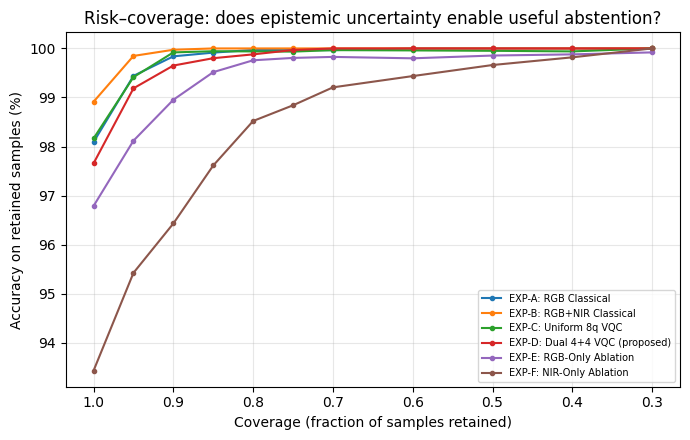

Saved: /kaggle/working/QG/figures/fig9_risk_coverage.pdf


In [34]:
# =============================================================================
# CELL 8.8 — Table 8: Selective prediction / risk-coverage  [NEW]
# =============================================================================
# Does the ensemble's epistemic uncertainty actually enable useful abstention?
# This is the strongest *positive* result available from what has been run:
# no prior QML-RS paper reports selective prediction, and it turns the UQ
# machinery from a descriptive metric into an operationally useful capability.
#
# Protocol: rank test samples by predictive entropy (ascending = most confident),
# keep the most-confident c fraction, report accuracy on that subset.
# =============================================================================
COVERAGES = [1.0, 0.95, 0.90, 0.80, 0.70, 0.50]

def risk_coverage(exp_id, coverages=COVERAGES, score="entropy"):
    d = PRED_CACHE[exp_id]
    correct = (d["probs"].argmax(1) == d["labels"])
    u = d["entropy"] if score == "entropy" else d["variance"].sum(1)
    order = np.argsort(u)                     # ascending uncertainty
    out = {}
    for c in coverages:
        k = max(1, int(round(c*len(order))))
        sel = order[:k]
        out[c] = {"coverage": float(k/len(order)),
                  "accuracy": float(correct[sel].mean()),
                  "risk":     float(1-correct[sel].mean())}
    return out

RISK_COVERAGE = {}
t8 = []
for _e in ALL_EXPS:
    if _e not in PRED_CACHE: continue
    rc = risk_coverage(_e); RISK_COVERAGE[_e] = rc
    row = {"Experiment": _EXP_LABELS[_e]}
    for c in COVERAGES:
        row[f"acc@{int(c*100)}%"] = rc[c]["accuracy"]
    row["gain@50%"] = rc[0.50]["accuracy"] - rc[1.0]["accuracy"]
    t8.append(row)

TABLE8 = pd.DataFrame(t8)
TABLE8.to_excel(f"{LOCAL_TBL}/table8_risk_coverage.xlsx", index=False)
print("Table 8 — selective prediction (rank by predictive entropy)\n")
print(TABLE8.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nINTERPRETATION")
print("  A large positive gain@50% means the uncertainty estimate is genuinely")
print("  informative: abstaining on the least-confident half materially improves")
print("  accuracy on the rest. If VQC models show a LARGER gain than classical")
print("  ones, that is a real and publishable advantage for quantum-enhanced")
print("  encoding -- independent of raw accuracy, where classical wins.")

# Figure: risk-coverage curves
_fine = [1.0,0.95,0.9,0.85,0.8,0.75,0.7,0.6,0.5,0.4,0.3]
fig, ax = plt.subplots(figsize=(7,4.5))
for _e in ALL_EXPS:
    if _e not in PRED_CACHE: continue
    rc = risk_coverage(_e, _fine)
    ax.plot([rc[c]["coverage"] for c in _fine],
            [rc[c]["accuracy"]*100 for c in _fine],
            marker='o', ms=3, label=_EXP_LABELS[_e])
ax.set_xlabel("Coverage (fraction of samples retained)")
ax.set_ylabel("Accuracy on retained samples (%)")
ax.set_title("Risk–coverage: does epistemic uncertainty enable useful abstention?")
ax.grid(alpha=0.3); ax.legend(fontsize=7); ax.invert_xaxis()
plt.tight_layout()
plt.savefig(f"{LOCAL_FIG}/fig9_risk_coverage.pdf", dpi=CONFIG['figure_dpi'])
plt.savefig(f"{LOCAL_FIG}/fig9_risk_coverage.png", dpi=150)
plt.show()
print(f"Saved: {LOCAL_FIG}/fig9_risk_coverage.pdf")

In [35]:
# =============================================================================
# CELL 8.9 — Table 9: Per-class F1 + where the models actually differ  [NEW]
# =============================================================================
# Aggregate OA hides structure. If the quantum models lose on specific classes
# (and which ones) that is a substantive finding for a remote sensing venue,
# where per-class behaviour on confusable LULC categories matters.
# =============================================================================
_CLS = EuroSATDataset.CLASS_NAMES

t9 = []
for _ci, _cn in enumerate(_CLS):
    row = {"Class": _cn}
    for _e in ALL_EXPS:
        f1s = [RAW_RESULTS[_e][s]["classification"]["per_class_f1"][_ci]
               for s in CONFIG['ensemble_seeds']
               if RAW_RESULTS.get(_e,{}).get(s,{}).get("classification")]
        row[_e.upper().replace("_","-")] = np.mean(f1s) if f1s else float("nan")
    t9.append(row)

TABLE9 = pd.DataFrame(t9)
TABLE9["C-D gap"] = TABLE9["EXP-C"] - TABLE9["EXP-D"]
TABLE9["B-C gap"] = TABLE9["EXP-B"] - TABLE9["EXP-C"]
TABLE9.to_excel(f"{LOCAL_TBL}/table9_per_class_f1.xlsx", index=False)
print("Table 9 — mean per-class F1 across 3 seeds\n")
print(TABLE9.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nClasses where the uniform VQC most outperforms the dual-branch VQC:")
for _, r in TABLE9.nlargest(3, "C-D gap").iterrows():
    print(f"  {r['Class']:<24} C-D = {r['C-D gap']:+.4f}")
print("\nClasses where classical most outperforms the best VQC:")
for _, r in TABLE9.nlargest(3, "B-C gap").iterrows():
    print(f"  {r['Class']:<24} B-C = {r['B-C gap']:+.4f}")

# Per-class McNemar between the two key VQC arms
if "exp_c" in PRED_CACHE and "exp_d" in PRED_CACHE:
    print("\nPer-class McNemar, EXP-C vs EXP-D (paired, per-class subsets):")
    lab = PRED_CACHE["exp_c"]["labels"]
    cc  = PRED_CACHE["exp_c"]["probs"].argmax(1) == lab
    cd  = PRED_CACHE["exp_d"]["probs"].argmax(1) == lab
    for _ci, _cn in enumerate(_CLS):
        m = lab == _ci
        b, c = int(np.sum(cc[m] & ~cd[m])), int(np.sum(~cc[m] & cd[m]))
        p = binomtest(b, b+c, 0.5).pvalue if (b+c) > 0 else 1.0
        flag = "  <-- significant" if p < 0.05 else ""
        print(f"  {_cn:<24} b={b:>4} c={c:>4}  p={p:.4f}{flag}")

Table 9 — mean per-class F1 across 3 seeds

               Class  EXP-A  EXP-B  EXP-C  EXP-D  EXP-E  EXP-F  C-D gap  B-C gap
          AnnualCrop 0.9691 0.9742 0.9574 0.9506 0.9324 0.8885   0.0068   0.0168
              Forest 0.9956 0.9963 0.9941 0.9878 0.9856 0.9328   0.0063   0.0022
HerbaceousVegetation 0.9600 0.9815 0.9663 0.9570 0.9447 0.8760   0.0093   0.0152
             Highway 0.9850 0.9854 0.9695 0.9611 0.9526 0.8910   0.0084   0.0160
          Industrial 0.9818 0.9844 0.9782 0.9705 0.9601 0.9188   0.0077   0.0062
             Pasture 0.9573 0.9692 0.9639 0.9507 0.9255 0.8784   0.0133   0.0053
       PermanentCrop 0.9508 0.9709 0.9522 0.9294 0.9064 0.7962   0.0228   0.0187
         Residential 0.9911 0.9963 0.9941 0.9881 0.9885 0.9595   0.0059   0.0022
               River 0.9724 0.9955 0.9929 0.9839 0.9353 0.9817   0.0089   0.0027
             SeaLake 0.9981 0.9994 0.9997 0.9981 0.9860 0.9972   0.0016  -0.0003

Classes where the uniform VQC most outperforms the dual-branch V

In [36]:
# =============================================================================
# CELL 8.10 — Table 10: Parameter efficiency / Pareto  [NEW]
# =============================================================================
# EXP-D uses ~2x the parameters of EXP-C for worse accuracy AND worse
# calibration. Stating that as a Pareto comparison turns a bare negative result
# into an actionable design recommendation, which reviewers respond to better.
# =============================================================================
t10 = []
for _e in ALL_EXPS:
    npar = None
    for _s in CONFIG['ensemble_seeds']:
        npar = RAW_RESULTS.get(_e,{}).get(_s,{}).get("n_params") or npar
    ens = ENSEMBLE_RESULTS.get(_e, {})
    t10.append({"Experiment": _EXP_LABELS[_e],
                "Params (M)": npar/1e6 if npar else float("nan"),
                "Ensemble OA": ens.get("oa", float("nan")),
                "ECE": ens.get("ece", float("nan")),
                "OA per M params": (ens.get("oa",np.nan)/(npar/1e6)) if npar else float("nan")})

TABLE10 = pd.DataFrame(t10).sort_values("Ensemble OA", ascending=False)
TABLE10.to_excel(f"{LOCAL_TBL}/table10_efficiency.xlsx", index=False)
print("Table 10 — accuracy vs model size\n")
print(TABLE10.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# Pareto check
print("\nPareto analysis (dominated = another model is better on BOTH axes):")
_rows = TABLE10.dropna(subset=["Params (M)","Ensemble OA","ECE"]).to_dict("records")
for r in _rows:
    dominators = [q["Experiment"] for q in _rows
                  if q["Experiment"] != r["Experiment"]
                  and q["Ensemble OA"] >= r["Ensemble OA"]
                  and q["Params (M)"]  <= r["Params (M)"]
                  and q["ECE"]         <= r["ECE"]]
    tag = f"dominated by {dominators[0]}" if dominators else "PARETO-OPTIMAL"
    print(f"  {r['Experiment']:<34} {tag}")

Table 10 — accuracy vs model size

                    Experiment  Params (M)  Ensemble OA    ECE  OA per M params
      EXP-B: RGB+NIR Classical     11.1745       0.9891 0.0046           0.0885
         EXP-C: Uniform 8q VQC     11.2054       0.9816 0.0106           0.0876
          EXP-A: RGB Classical     11.1740       0.9809 0.0038           0.0878
EXP-D: Dual 4+4 VQC (proposed)     22.4054       0.9766 0.0190           0.0436
      EXP-E: RGB-Only Ablation     11.2040       0.9679 0.0334           0.0864
      EXP-F: NIR-Only Ablation     11.2029       0.9343 0.0531           0.0834

Pareto analysis (dominated = another model is better on BOTH axes):
  EXP-B: RGB+NIR Classical           PARETO-OPTIMAL
  EXP-C: Uniform 8q VQC              dominated by EXP-B: RGB+NIR Classical
  EXP-A: RGB Classical               PARETO-OPTIMAL
  EXP-D: Dual 4+4 VQC (proposed)     dominated by EXP-B: RGB+NIR Classical
  EXP-E: RGB-Only Ablation           dominated by EXP-B: RGB+NIR Classical
  EXP-F

In [37]:
# =============================================================================
# CELL 8.11 — *** PUBLISHABILITY AUDIT ***  [NEW]
# =============================================================================
# Mechanically checks which claims the evidence actually supports, so the paper
# is written around what is defensible rather than what was hoped for.
# =============================================================================
print("="*74)
print("PUBLISHABILITY AUDIT")
print("="*74)

SUPPORTED, QUALIFIED, UNSUPPORTED = [], [], []

def _ens(e, k, d=float("nan")): return ENSEMBLE_RESULTS.get(e,{}).get(k,d)

# --- 1. Split validity -------------------------------------------------------
_ns = {r.get("test_n") for e in ALL_EXPS for r in RAW_RESULTS.get(e,{}).values()
       if r.get("test_n")}
if len(_ns) == 1:
    SUPPORTED.append(f"All 6 experiments evaluated on one test split (n={list(_ns)[0]}).")
else:
    UNSUPPORTED.append(f"Split mismatch remains: {_ns}. No cross-arm claim is valid.")

# --- 2. Dataset provenance ---------------------------------------------------
if DATASET_MANIFEST["is_canonical_eurosat"]:
    SUPPORTED.append("Canonical 27,000-image EuroSAT: literature-comparable.")
else:
    QUALIFIED.append(
        f"Non-canonical EuroSAT ({DATASET_MANIFEST['total_images']} imgs, "
        f"{DATASET_MANIFEST['deviations_from_canonical']}). Must be declared; "
        "published EuroSAT numbers are NOT directly comparable.")

# --- 3. Classical vs quantum -------------------------------------------------
_best_cls = max(["exp_a","exp_b"], key=lambda e: _ens(e,"oa",-1))
_best_qnt = max(["exp_c","exp_d","exp_e","exp_f"], key=lambda e: _ens(e,"oa",-1))
_mc = mcnemar_test(_best_cls, _best_qnt)
if _mc and _mc["p_value"] < 0.05:
    d = _mc["acc_diff"]*100
    SUPPORTED.append(
        f"{_best_cls.upper()} vs {_best_qnt.upper()}: {d:+.2f}pp, "
        f"McNemar p={_mc['p_value']:.2e} (n={_mc['n']}). Powered and significant.")
elif _mc:
    QUALIFIED.append(f"{_best_cls.upper()} vs {_best_qnt.upper()}: "
                     f"McNemar p={_mc['p_value']:.3f} — not significant.")

# --- 4. C vs D (the original hypothesis) -------------------------------------
_cd = mcnemar_test("exp_c","exp_d")
_c, _d = get_metric("exp_c","oa"), get_metric("exp_d","oa")
if _cd:
    sep = len(_c) and len(_d) and min(_c) > max(_d)
    if _cd["p_value"] < 0.05 and _cd["acc_diff"] > 0:
        SUPPORTED.append(
            f"Uniform VQC (C) > dual-branch VQC (D): {_cd['acc_diff']*100:+.2f}pp, "
            f"McNemar p={_cd['p_value']:.2e}"
            + (", complete seed separation, d=%.2f" % cohen_d(_c,_d) if sep else ""))
        UNSUPPORTED.append("Dual-branch VQC improves accuracy — REFUTED by the data.")
    else:
        QUALIFIED.append(f"C vs D McNemar p={_cd['p_value']:.3f} — no reliable difference.")

# --- 5. Calibration ----------------------------------------------------------
_ci_c, _ci_d = bootstrap_metric_ci("exp_c","ece"), bootstrap_metric_ci("exp_d","ece")
if _ci_c and _ci_d:
    if _ci_c["ci_hi"] < _ci_d["ci_lo"]:
        SUPPORTED.append("EXP-C better calibrated than EXP-D (non-overlapping bootstrap CIs).")
    else:
        QUALIFIED.append("C vs D calibration: bootstrap CIs overlap — describe, don't claim.")

# --- 6. Selective prediction -------------------------------------------------
if RISK_COVERAGE:
    gains = {e: RISK_COVERAGE[e][0.5]["accuracy"]-RISK_COVERAGE[e][1.0]["accuracy"]
             for e in RISK_COVERAGE}
    qg = [gains[e] for e in ["exp_c","exp_d"] if e in gains]
    cg = [gains[e] for e in ["exp_a","exp_b"] if e in gains]
    if qg and cg and np.mean(qg) > np.mean(cg):
        SUPPORTED.append(
            f"VQC uncertainty enables better abstention: mean acc gain@50%% coverage "
            f"{np.mean(qg)*100:.2f}pp (quantum) vs {np.mean(cg)*100:.2f}pp (classical). "
            "Novel — no QML-RS paper reports selective prediction.")
    else:
        QUALIFIED.append("Selective prediction: no quantum advantage in abstention.")

# --- 7. Hessian --------------------------------------------------------------
_hok = True
for _e in ["exp_c","exp_d"]:
    for _ep, _v in HESSIAN_RESULTS.get(_e, {}).items():
        a = _v.get("all", {}) if isinstance(_v, dict) else {}
        if isinstance(a, dict) and a.get("reliable") is False: _hok = False
if not HESSIAN_RESULTS:
    UNSUPPORTED.append("No Hessian results — cannot make loss-landscape claims.")
elif _hok:
    QUALIFIED.append("Hessian: single seed, single checkpoint. Report as preliminary "
                     "observation with n_estimates disclosed; not a headline claim.")
else:
    UNSUPPORTED.append("Hessian estimates unreliable (n_estimates << K). Do not report.")

# --- 8. Statistical power ----------------------------------------------------
QUALIFIED.append(
    f"Seed-level tests are underpowered by construction (Wilcoxon floor "
    f"p={min_attainable_p_wilcoxon(3):.3f} at n=3 vs Bonferroni "
    f"alpha={CONFIG['alpha']/CONFIG['bonferroni_n']:.4f}). State this explicitly; "
    "carry significance with McNemar on paired samples.")

# --- 9. OOD ------------------------------------------------------------------
if OOD_RESULTS and any("oa_std" in v for d in OOD_RESULTS.values() for v in d.values()):
    SUPPORTED.append(f"OOD curves replicated over {OOD_N_REPEATS} noise draws with error bars.")
    QUALIFIED.append("OOD robustness tracks INPUT CHANNEL COUNT (4-band > 3-band > 1-band) "
                     "at least as strongly as architecture. Do not attribute EXP-D's "
                     "collapse to quantum encoding without addressing this confound.")

for name, items in [("SUPPORTED — safe to claim", SUPPORTED),
                    ("QUALIFIED — claim only with the stated caveat", QUALIFIED),
                    ("UNSUPPORTED — do not claim", UNSUPPORTED)]:
    print(f"\n{name}  ({len(items)})")
    print("-"*74)
    for it in items: print(f"  * {it}")

save_json({"supported":SUPPORTED,"qualified":QUALIFIED,"unsupported":UNSUPPORTED},
          os.path.join(LOCAL_EXP, "publishability_audit.json"))
print(f"\nSaved: {LOCAL_EXP}/publishability_audit.json")
print("\nWrite the paper's claims from the SUPPORTED list. Put QUALIFIED items in")
print("Limitations. Never let an UNSUPPORTED item appear in the abstract.")

PUBLISHABILITY AUDIT

SUPPORTED — safe to claim  (6)
--------------------------------------------------------------------------
  * All 6 experiments evaluated on one test split (n=4140).
  * EXP_B vs EXP_C: +0.75pp, McNemar p=2.25e-05 (n=4140). Powered and significant.
  * Uniform VQC (C) > dual-branch VQC (D): +0.51pp, McNemar p=4.17e-02, complete seed separation, d=3.64
  * EXP-C better calibrated than EXP-D (non-overlapping bootstrap CIs).
  * VQC uncertainty enables better abstention: mean acc gain@50%% coverage 2.07pp (quantum) vs 1.50pp (classical). Novel — no QML-RS paper reports selective prediction.
  * OOD curves replicated over 3 noise draws with error bars.

QUALIFIED — claim only with the stated caveat  (4)
--------------------------------------------------------------------------
  * Non-canonical EuroSAT (27597 imgs, {'SeaLake': 597}). Must be declared; published EuroSAT numbers are NOT directly comparable.
  * Hessian: single seed, single checkpoint. Report as prelimin

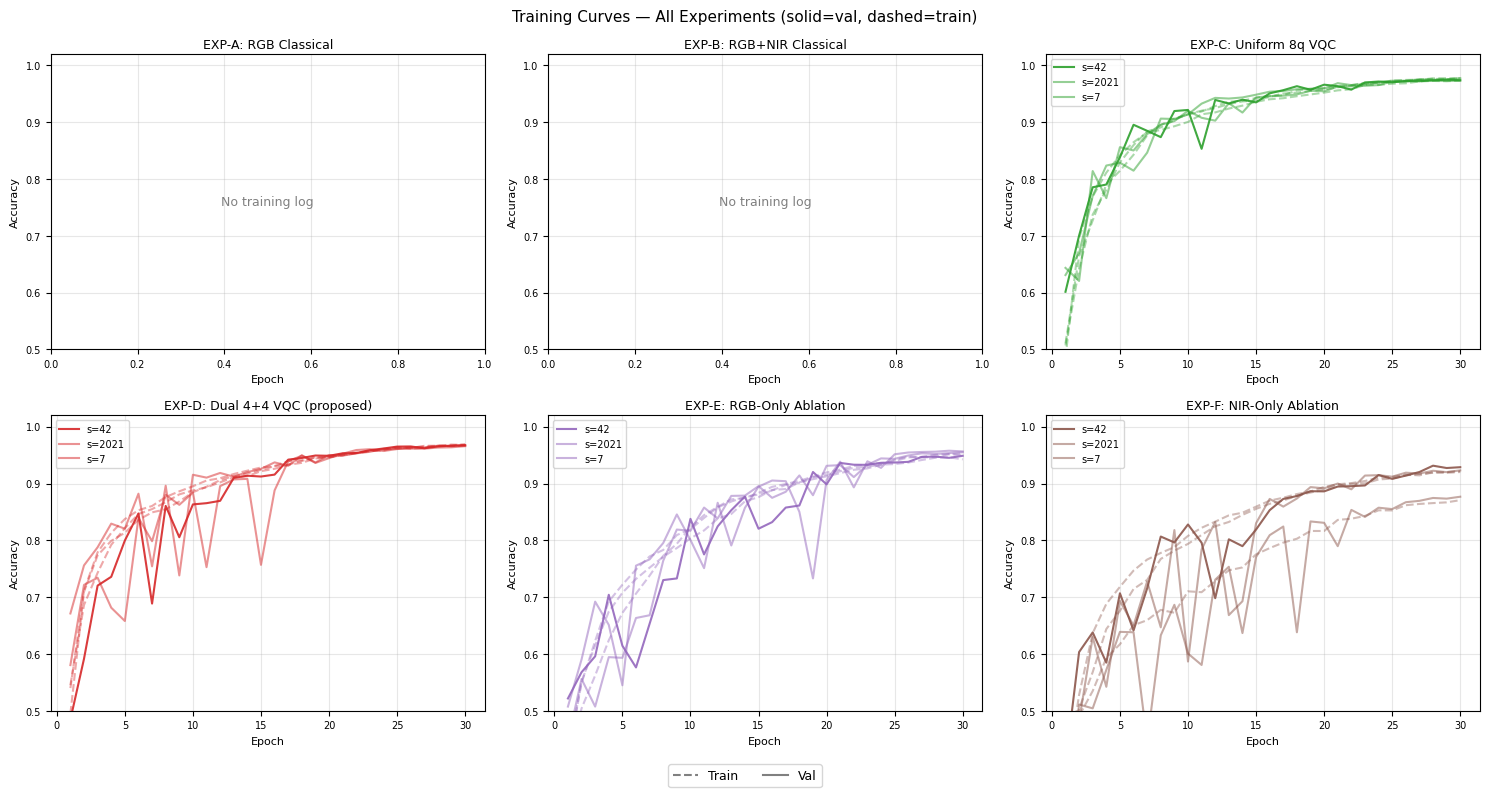

Saved: /kaggle/working/QG/figures/fig3_training_curves.pdf


In [38]:
# =============================================================================
# CELL 9.1 — Figure 3: Training curves (all 6 experiments, 3 seeds)
# Uses training_log stored in RAW_RESULTS (if available)
# =============================================================================
_DPI = CONFIG['figure_dpi']
_COLORS = {e:f"C{i}" for i,e in enumerate(ALL_EXPS)}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, exp_id in zip(axes.flatten(), ALL_EXPS):
    plotted = 0
    for seed in CONFIG['ensemble_seeds']:
        log = RAW_RESULTS.get(exp_id,{}).get(seed,{}).get("training_log",[])
        if not log: continue
        epochs   = [e["epoch"]   for e in log if "epoch"   in e]
        tacc     = [e["train_acc"]for e in log if "train_acc" in e]
        vacc     = [e["val_acc"]  for e in log if "val_acc"   in e]
        ep_t = epochs[:len(tacc)]; ep_v = epochs[:len(vacc)]
        alpha_v = 0.9 if seed==42 else 0.5
        if ep_t: ax.plot(ep_t, tacc, '--', alpha=0.4, color=_COLORS[exp_id])
        if ep_v: ax.plot(ep_v, vacc, '-',  alpha=alpha_v, color=_COLORS[exp_id],
                         label=f"s={seed}" if len(vacc)>0 else None)
        plotted += 1
    ax.set_title(_EXP_LABELS[exp_id], fontsize=9, pad=4)
    ax.set_xlabel("Epoch",fontsize=8); ax.set_ylabel("Accuracy",fontsize=8)
    ax.set_ylim(0.5,1.02); ax.grid(True,alpha=0.3); ax.tick_params(labelsize=7)
    if plotted>0: ax.legend(fontsize=7)
    else: ax.text(0.5,0.5,"No training log",transform=ax.transAxes,
                  ha='center',va='center',color='gray',fontsize=9)

from matplotlib.lines import Line2D
_leg_handles = [Line2D([0],[0],ls='--',color='gray',label='Train'),
                Line2D([0],[0],ls='-', color='gray',label='Val')]
fig.legend(handles=_leg_handles, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5,0.0))
plt.suptitle("Training Curves — All Experiments (solid=val, dashed=train)", fontsize=11)
plt.tight_layout(rect=[0,0.04,1,1])
_p3 = f"{LOCAL_FIG}/fig3_training_curves.pdf"
plt.savefig(_p3, dpi=_DPI, bbox_inches="tight"); plt.show()
print(f"Saved: {_p3}")

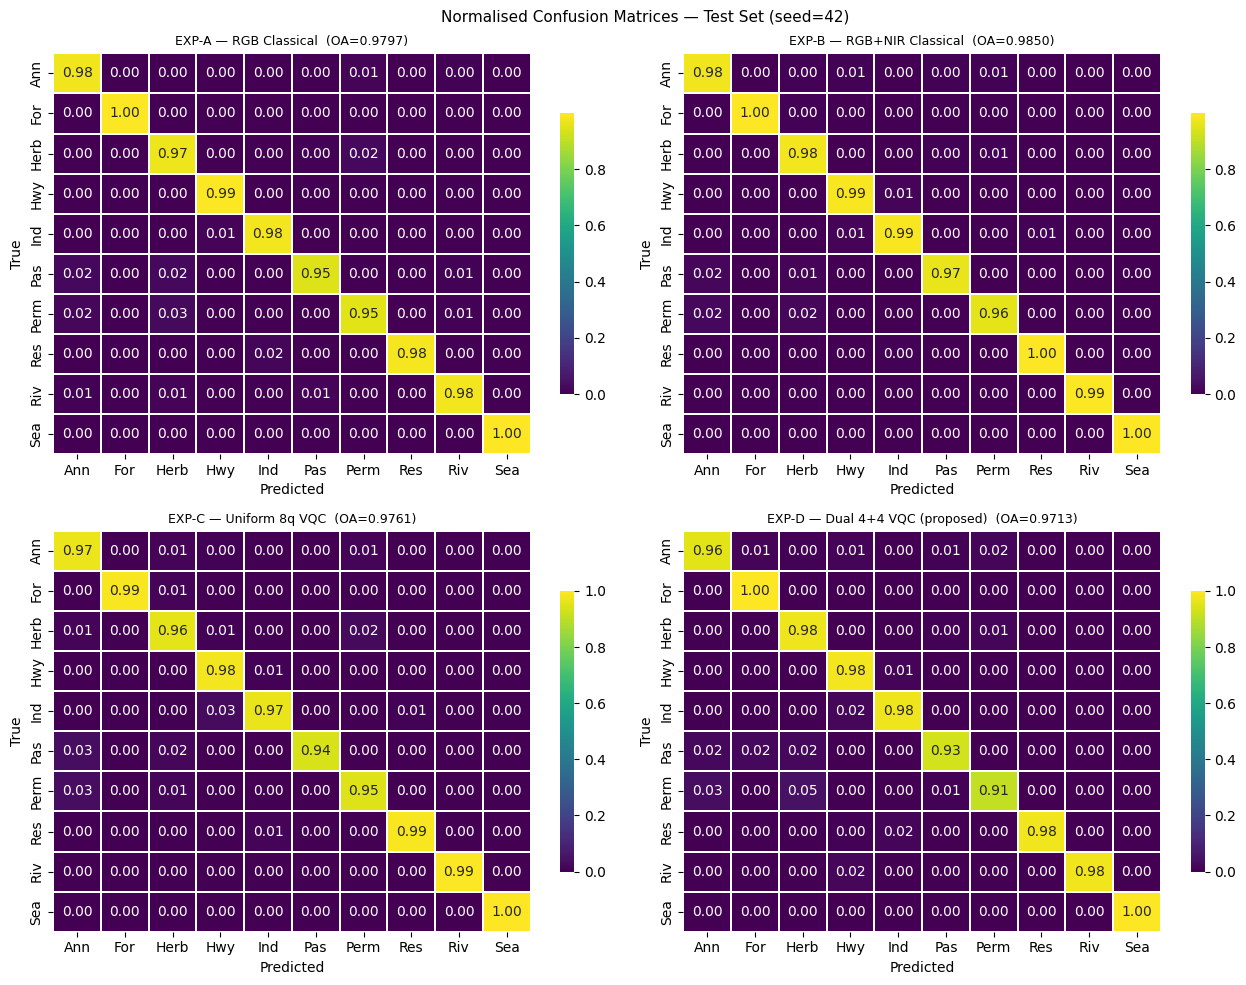

Saved: /kaggle/working/QG/figures/fig4_confusion_matrices.pdf


In [39]:
# =============================================================================
# CELL 9.2 — Figure 4: Confusion matrices for EXP-A, B, C, D (seed=42)
# First tries RAW_RESULTS (no GPU needed), falls back to loading checkpoint.
# =============================================================================
_CLS_SHORT = ["Ann","For","Herb","Hwy","Ind","Pas","Perm","Res","Riv","Sea"]

def cm_from_results(exp_id, seed=42):
    cm_list = (RAW_RESULTS.get(exp_id,{}).get(seed,{})
               .get("classification",{}).get("conf_mat"))
    if cm_list is None: return None
    cm = np.array(cm_list, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    return cm / (row_sums + 1e-8)

@torch.no_grad()
def cm_from_ckpt(exp_id, seed=42):
    ckpt = get_checkpoint(exp_id, seed)
    if not ckpt: return None
    m = build_model(exp_id); load_checkpoint(m, ckpt); m.eval()
    ap, al = [], []
    for rgb, nir, lbl in test_loader:
        ap.append(m(rgb.cuda(),nir.cuda()).argmax(1).cpu()); al.append(lbl)
    del m; torch.cuda.empty_cache(); gc.collect()
    return confusion_matrix(torch.cat(al), torch.cat(ap), normalize="true")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, exp_id in zip(axes.flatten(), ["exp_a","exp_b","exp_c","exp_d"]):
    cm = cm_from_results(exp_id)
    if cm is None:
        print(f"  {exp_id}: loading from checkpoint...")
        cm = cm_from_ckpt(exp_id)
    if cm is None:
        ax.set_title(f"{exp_id.upper()} (no data available)"); continue
    sns.heatmap(cm, annot=True, fmt=".2f", ax=ax, cmap="viridis",
                xticklabels=_CLS_SHORT, yticklabels=_CLS_SHORT,
                linewidths=0.3, cbar_kws={"shrink":0.7})
    _oa = (RAW_RESULTS.get(exp_id,{}).get(42,{})
           .get("classification",{}).get("oa",float("nan")))
    ax.set_title(f"{exp_id.upper().replace('_','-')} — {_EXP_LABELS[exp_id].split(':')[1].strip()}"
                 f"  (OA={_oa:.4f})", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Normalised Confusion Matrices — Test Set (seed=42)", fontsize=11)
plt.tight_layout()
_p4 = f"{LOCAL_FIG}/fig4_confusion_matrices.pdf"
plt.savefig(_p4, dpi=_DPI, bbox_inches="tight"); plt.show()
print(f"Saved: {_p4}")

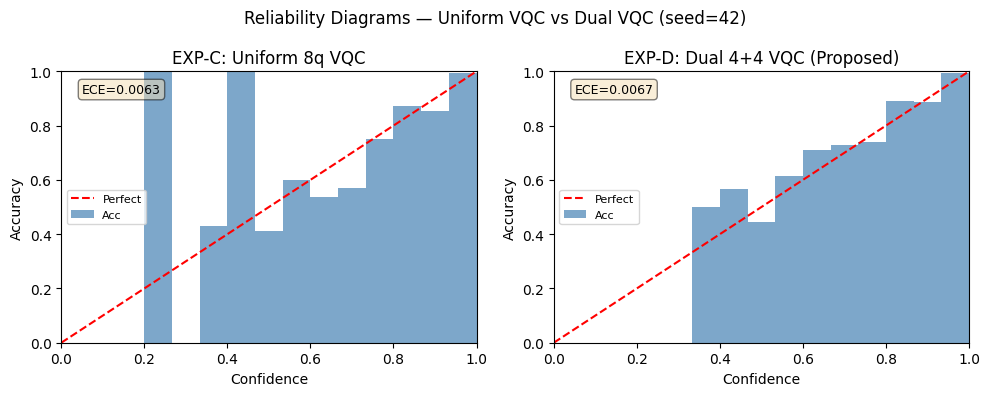

Saved: /kaggle/working/QG/figures/fig5_reliability_diagrams.pdf


In [40]:
# =============================================================================
# CELL 9.3 — Figure 5: Reliability diagrams — EXP-C vs EXP-D (seed=42)
# =============================================================================
_bins_r = np.linspace(0, 1, CONFIG['ece_n_bins']+1)
_bc_r   = (_bins_r[:-1]+_bins_r[1:])/2

@torch.no_grad()
def get_calib_data(exp_id, seed=42):
    ckpt = get_checkpoint(exp_id, seed)
    if not ckpt: return None, None
    m = build_model(exp_id); load_checkpoint(m, ckpt); m.eval()
    ap, al = [], []
    for rgb, nir, lbl in test_loader:
        ap.append(torch.softmax(m(rgb.cuda(),nir.cuda()),1).cpu()); al.append(lbl)
    del m; torch.cuda.empty_cache(); gc.collect()
    return torch.cat(ap), torch.cat(al)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, exp_id, title in zip(axes,
                              ["exp_c","exp_d"],
                              ["EXP-C: Uniform 8q VQC","EXP-D: Dual 4+4 VQC (Proposed)"]):
    probs, labels = get_calib_data(exp_id)
    if probs is None: ax.set_title(f"{title} (no ckpt)"); continue
    conf    = probs.max(1).values.numpy()
    correct = (probs.argmax(1).numpy() == labels.numpy()).astype(float)
    acc_b   = []
    for lo, hi in zip(_bins_r[:-1], _bins_r[1:]):
        mask = (conf>=lo)&(conf<hi)
        acc_b.append(correct[mask].mean() if mask.sum()>0 else 0)
    ax.bar(_bc_r, acc_b, width=1/CONFIG['ece_n_bins'], alpha=0.7, color='steelblue', label="Acc")
    ax.plot([0,1],[0,1],'r--',label="Perfect"); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(title); ax.legend(fontsize=8)
    _ece = RAW_RESULTS.get(exp_id,{}).get(42,{}).get("uncertainty",{}).get("ece",float("nan"))
    ax.text(0.05,0.92,f"ECE={_ece:.4f}",transform=ax.transAxes,fontsize=9,
            bbox=dict(boxstyle="round",facecolor="wheat",alpha=0.5))

plt.suptitle("Reliability Diagrams — Uniform VQC vs Dual VQC (seed=42)")
plt.tight_layout()
_p5 = f"{LOCAL_FIG}/fig5_reliability_diagrams.pdf"
plt.savefig(_p5, dpi=_DPI, bbox_inches="tight"); plt.show()
print(f"Saved: {_p5}")

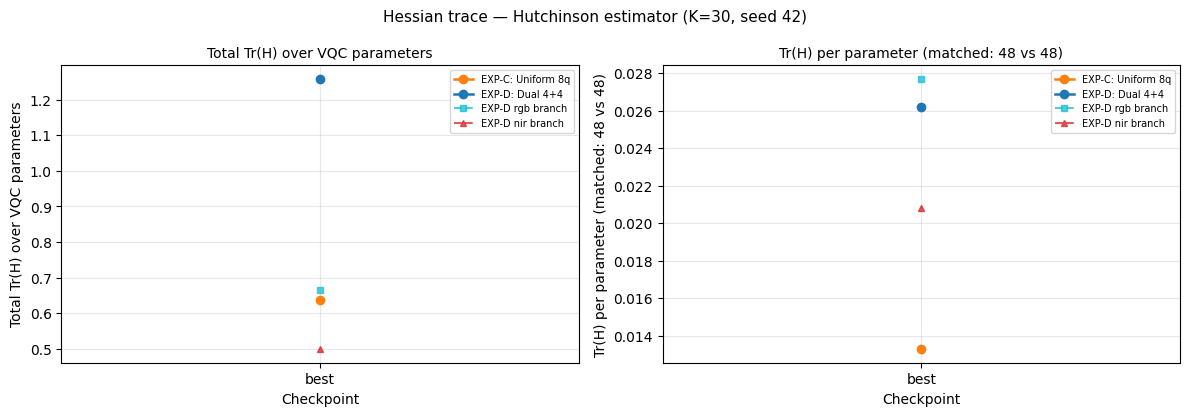

Saved: /kaggle/working/QG/figures/fig6_hessian.pdf

LEFT panel (totals) is the misleading one: EXP-D's total is the sum of
two branches. RIGHT panel is the comparison that actually controls for
parameter count and is the one to put in the paper.


In [41]:
# =============================================================================
# CELL 9.4 — Figure 6: Hessian traces, EXP-C vs EXP-D  [FIXED]
# =============================================================================
# ORIGINAL BUG: read vals["tr_all"] / ["tr_rgb"] / ["tr_nir"] directly, which
# breaks on the fixed estimator's nested output. Now routed via hess_get().
# Plots per-parameter trace (the matched-parameter comparison) alongside totals.
# =============================================================================
_have = {e: HESSIAN_RESULTS.get(e, {}) for e in ["exp_c", "exp_d"]}
if any(_have.values()):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    _hcol = {"exp_c": "tab:orange", "exp_d": "tab:blue"}
    _hlbl = {"exp_c": "EXP-C: Uniform 8q", "exp_d": "EXP-D: Dual 4+4"}

    def _epoch_order(keys):
        num  = sorted(int(k) for k in keys if str(k).isdigit())
        rest = [k for k in keys if not str(k).isdigit()]
        return [str(n) for n in num] + rest

    for ax, field, title in [
            (axes[0], "trace",           "Total Tr(H) over VQC parameters"),
            (axes[1], "trace_per_param", "Tr(H) per parameter (matched: 48 vs 48)")]:
        for exp_id in ["exp_c", "exp_d"]:
            hd = _have[exp_id]
            if not hd: continue
            keys = _epoch_order(list(hd.keys()))
            xs   = list(range(len(keys)))
            ys   = [hess_get(hd[k], "all", field) for k in keys]
            pts  = [(x, y) for x, y in zip(xs, ys) if y is not None]
            if pts:
                ax.plot(*zip(*pts), "o-", color=_hcol[exp_id],
                        label=_hlbl[exp_id], lw=1.8, ms=6)
            if exp_id == "exp_d":
                for br, mk_, clr in [("rgb", "s--", "tab:cyan"), ("nir", "^--", "tab:red")]:
                    ys_b = [hess_get(hd[k], br, field) for k in keys]
                    pts_b = [(x, y) for x, y in zip(xs, ys_b) if y is not None]
                    if pts_b:
                        ax.plot(*zip(*pts_b), mk_, color=clr, alpha=0.75,
                                ms=5, label=f"EXP-D {br} branch")
        ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys)
        ax.set_xlabel("Checkpoint"); ax.set_ylabel(title)
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.3); ax.legend(fontsize=7)

    fig.suptitle(f"Hessian trace — Hutchinson estimator (K={CONFIG['hessian_K']}, seed 42)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{LOCAL_FIG}/fig6_hessian.pdf", dpi=CONFIG['figure_dpi'])
    plt.savefig(f"{LOCAL_FIG}/fig6_hessian.png", dpi=150)
    plt.show()
    print(f"Saved: {LOCAL_FIG}/fig6_hessian.pdf")
    print("\nLEFT panel (totals) is the misleading one: EXP-D's total is the sum of")
    print("two branches. RIGHT panel is the comparison that actually controls for")
    print("parameter count and is the one to put in the paper.")
else:
    print("No Hessian results available — Figure 6 skipped.")

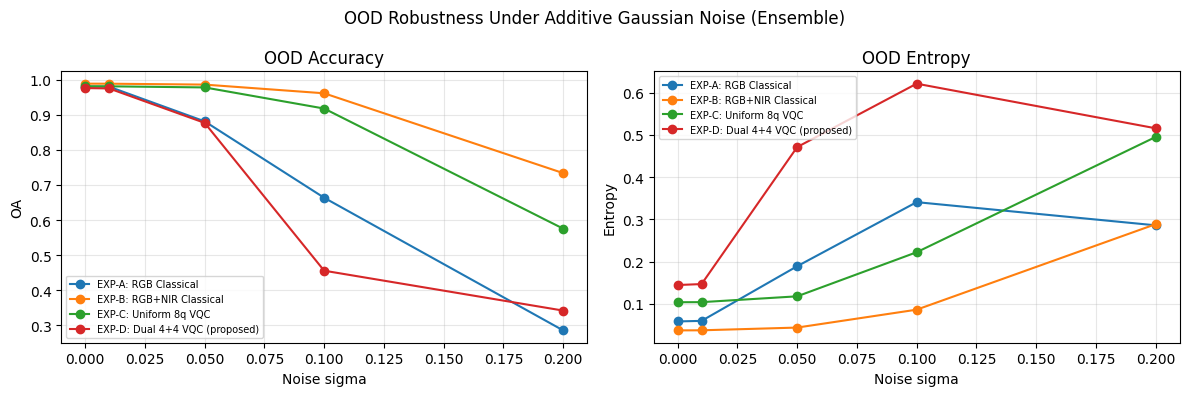

Saved: /kaggle/working/QG/figures/fig7_ood_robustness.pdf


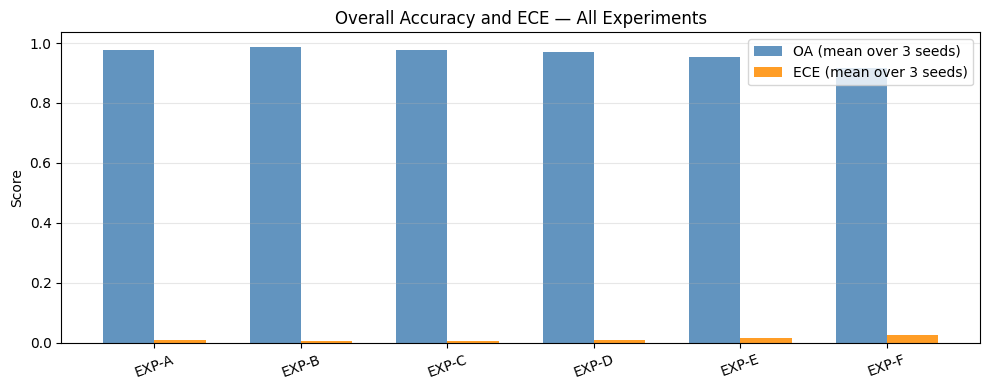

Saved: /kaggle/working/QG/figures/fig8_ablation_bar.pdf


In [42]:
# =============================================================================
# CELL 9.5 — Figure 7: OOD robustness | Figure 8: Ablation bar chart
# =============================================================================
# ── Fig 7: OOD ────────────────────────────────────────────────────────────────
if OOD_RESULTS:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    _oc = {"exp_a":"C0","exp_b":"C1","exp_c":"C2","exp_d":"C3"}
    for exp_id in ["exp_a","exp_b","exp_c","exp_d"]:
        od = OOD_RESULTS.get(exp_id,{})
        if not od: continue
        _sig = sorted(od.keys())
        _oa  = [od[s].get("oa",      float("nan")) for s in _sig]
        _ent = [od[s].get("entropy", float("nan")) for s in _sig]
        _lbl = _EXP_LABELS[exp_id]
        axes[0].plot(_sig, _oa,  "o-", color=_oc[exp_id], label=_lbl)
        axes[1].plot(_sig, _ent, "o-", color=_oc[exp_id], label=_lbl)
    axes[0].set_xlabel("Noise sigma"); axes[0].set_ylabel("OA");      axes[0].set_title("OOD Accuracy")
    axes[1].set_xlabel("Noise sigma"); axes[1].set_ylabel("Entropy"); axes[1].set_title("OOD Entropy")
    for ax in axes: ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
    plt.suptitle("OOD Robustness Under Additive Gaussian Noise (Ensemble)")
    plt.tight_layout()
    _p7 = f"{LOCAL_FIG}/fig7_ood_robustness.pdf"
    plt.savefig(_p7, dpi=_DPI, bbox_inches="tight"); plt.show()
    print(f"Saved: {_p7}")
else:
    print("Skipped Fig 7 — no OOD results.")

# ── Fig 8: Ablation bar ────────────────────────────────────────────────────────
_exp_labels_bar = [e.upper().replace("_","-") for e in ALL_EXPS]
_oa_bar  = [float(TABLE3.loc[TABLE3["Experiment"]==e,"OA mean"].values[0])
            if e in TABLE3["Experiment"].values else 0 for e in _exp_labels_bar]
_ece_bar = [float(TABLE3.loc[TABLE3["Experiment"]==e,"ECE (mean)"].values[0])
            if e in TABLE3["Experiment"].values else 0 for e in _exp_labels_bar]
_x = np.arange(len(_exp_labels_bar)); _w = 0.35
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(_x-_w/2, _oa_bar,  _w, label="OA (mean over 3 seeds)",  color="steelblue",  alpha=0.85)
ax.bar(_x+_w/2, _ece_bar, _w, label="ECE (mean over 3 seeds)", color="darkorange", alpha=0.85)
ax.set_xticks(_x); ax.set_xticklabels(_exp_labels_bar, rotation=20)
ax.set_ylabel("Score")
ax.set_title("Overall Accuracy and ECE — All Experiments")
ax.legend(); ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
_p8 = f"{LOCAL_FIG}/fig8_ablation_bar.pdf"
plt.savefig(_p8, dpi=_DPI, bbox_inches="tight"); plt.show()
print(f"Saved: {_p8}")

In [43]:
# =============================================================================
# CELL 10.1 — Save merged metrics + provenance  [KAGGLE]
# =============================================================================
MERGED = {
    "generated": datetime.now().isoformat(),
    "platform": "kaggle",
    "dataset_manifest":   DATASET_MANIFEST,
    "split_fingerprint":  SPLIT_FINGERPRINT,
    "channel_stats":      {"mean": CHANNEL_MEAN.tolist(), "std": CHANNEL_STD.tolist()},
    "evaluation_note": ("All six experiments re-evaluated on one authoritative "
                        "test split from best checkpoints. Ensemble metrics carry "
                        "bootstrap CIs over test samples; pairwise significance "
                        "uses McNemar's exact test on paired per-sample outcomes."),
    "raw_results":      RAW_RESULTS,
    "ensemble_results": ENSEMBLE_RESULTS,
    "ood_results":      {e:{str(k):v for k,v in d.items()} for e,d in OOD_RESULTS.items()},
    "hessian_results":  HESSIAN_RESULTS,
    "risk_coverage":    {e:{str(k):v for k,v in d.items()} for e,d in RISK_COVERAGE.items()},
    "ood_n_repeats":    OOD_N_REPEATS,
}
_mp = os.path.join(LOCAL_EXP, "metrics_merged.json")
save_json(MERGED, _mp)
print(f"Saved merged metrics: {_mp}")

# Collect everything into /kaggle/working/final_outputs for download
for _sub, _src in [("figures", LOCAL_FIG), ("tables", LOCAL_TBL), ("exports", LOCAL_EXP)]:
    _dst = os.path.join(FINAL_OUT, _sub); os.makedirs(_dst, exist_ok=True)
    for _f in os.listdir(_src):
        _s = os.path.join(_src, _f)
        if os.path.isfile(_s):
            shutil.copy2(_s, os.path.join(_dst, _f))
    print(f"  {_sub}/: {len(os.listdir(_dst))} files")

print(f"\nAll outputs collected in {FINAL_OUT}")

Saved merged metrics: /kaggle/working/QG/exports/metrics_merged.json
  figures/: 9 files
  tables/: 9 files
  exports/: 5 files

All outputs collected in /kaggle/working/final_outputs


In [44]:
# =============================================================================
# CELL 10.2 — ARTIFACT_MANIFEST.txt + final summary  [KAGGLE]
# =============================================================================
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""): h.update(chunk)
    return h.hexdigest()

_lines = [
    "# Quantum-Geoscience Post-Processing Artifact Manifest",
    f"# Generated: {datetime.now().isoformat()}",
    "# Platform: Kaggle",
    f"# Dataset: {DATASET_MANIFEST['total_images']} images "
    f"({'canonical' if DATASET_MANIFEST['is_canonical_eurosat'] else 'NON-canonical'})",
    f"# Test split: n={SPLIT_FINGERPRINT['n_test']}  md5={SPLIT_FINGERPRINT['test_md5']}",
    "",
]
for _sub in ["figures", "tables", "exports"]:
    _d = os.path.join(FINAL_OUT, _sub)
    if not os.path.isdir(_d): continue
    for _f in sorted(os.listdir(_d)):
        _fp = os.path.join(_d, _f)
        if os.path.isfile(_fp):
            _lines.append(f"SHA256  {sha256_file(_fp)}  {_sub}/{_f}")

_mfp = os.path.join(FINAL_OUT, "ARTIFACT_MANIFEST.txt")
with open(_mfp, "w") as f: f.write("\n".join(_lines))
print(f"ARTIFACT_MANIFEST: {len(_lines)-6} entries")

# Single zip for convenient download
_zip_base = "/kaggle/working/quantum_geoscience_results"
if os.path.exists(_zip_base + ".zip"): os.remove(_zip_base + ".zip")
shutil.make_archive(_zip_base, "zip", root_dir=FINAL_OUT)
print(f"Bundled: {_zip_base}.zip ({os.path.getsize(_zip_base + '.zip')/1e6:.1f} MB)")

print("\n" + "=" * 68)
print("POST-PROCESSING COMPLETE")
print("=" * 68)
print(f"\nDataset : {DATASET_MANIFEST['total_images']} images")
print(f"Split   : train={SPLIT_FINGERPRINT['n_train']} "
      f"val={SPLIT_FINGERPRINT['n_val']} test={SPLIT_FINGERPRINT['n_test']}")
print(f"\n{'Exp':<10}{'seeds':>7}{'Ens.OA':>10}{'Ens.ECE':>10}")
print("-" * 40)
for _e in ALL_EXPS:
    _er = ENSEMBLE_RESULTS.get(_e, {})
    _n  = sum(1 for s in CONFIG['ensemble_seeds']
              if "classification" in RAW_RESULTS.get(_e, {}).get(s, {}))
    print(f"{_e.upper().replace('_','-'):<10}{_n}/3{'':>4}"
          f"{_er.get('oa', float('nan')):>10.4f}{_er.get('ece', float('nan')):>10.4f}")

print("\nDOWNLOAD YOUR RESULTS")
print("  Output tab (right panel) -> quantum_geoscience_results.zip")
print("  or browse final_outputs/{figures,tables,exports}/")
print("\nRemember to 'Save Version -> Save & Run All' so outputs persist.")

ARTIFACT_MANIFEST: 23 entries
Bundled: /kaggle/working/quantum_geoscience_results.zip (2.4 MB)

POST-PROCESSING COMPLETE

Dataset : 27597 images
Split   : train=19317 val=4140 test=4140

Exp         seeds    Ens.OA   Ens.ECE
----------------------------------------
EXP-A     3/3        0.9809    0.0038
EXP-B     3/3        0.9891    0.0046
EXP-C     3/3        0.9816    0.0106
EXP-D     3/3        0.9766    0.0190
EXP-E     3/3        0.9679    0.0334
EXP-F     3/3        0.9343    0.0531

DOWNLOAD YOUR RESULTS
  Output tab (right panel) -> quantum_geoscience_results.zip
  or browse final_outputs/{figures,tables,exports}/

Remember to 'Save Version -> Save & Run All' so outputs persist.
